[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter9_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 9: VaR, ES and backtesting

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Scoring functions for quantiles and for (VaR, ES): pinball, FZ0, Murphy diagrams.
- CAViaR (Engle and Manganelli 2004) and the semiparametric GAS models of Patton, Ziegel and Chen (2019), replicated on our data and extended to 2026.
- Backtests as tests of conditional calibration, estimation risk, the model confidence set in stress periods.
- The horizon (square-root-of-time), model risk, extremes under dependence, adaptive conformal calibration.
- Conventions: returns in %, VaR 1% is the 1% quantile of returns with the sign changed, ES 2.5% the 2.5% tail mean.
- Some computations use fewer replications than the slides, to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The numpy engine and the data helpers

- Losses: `pinball`, `fz0`, `murphy_quantile`; distributions: skewed t, Student t, Normal.
- Benchmarks: `rolling_hs`, `garch_fit`, `arma_bic`; CAViaR: `caviar_fit`, `caviar_se`, `dq_test`.
- Semiparametric models: `fz_paths`, `fz_fit` (FZ0 minimisation), `es_regression`.
- Backtests and comparison: `kupiec`, `christoffersen`, `cp_duration_test`, `pzc_gof`, `mcneil_frey`, `dm_test`, `mcs`.
- `run_asset` estimates the ten models of PZC once per asset (parameters fixed on the first ten years).

In [5]:
import pickle
from scipy import special, integrate
try:                                    # numba accelerates the recursions; without it the code runs in plain Python
    from numba import njit as _njit

    def njit(*args, **kw):
        kw.pop('cache', None)           # no on-disk cache for functions defined in a notebook
        return _njit(*args, **kw)
except ImportError:
    def njit(*args, **kw):
        if args and callable(args[0]):
            return args[0]
        return lambda f: f
SEED = 2026
END = '2026-09-18'
ASSETS = {'sp500': ('1990-01-01', '2000-01-01'), 'dax': ('1990-01-01', '2000-01-01'), 'bet': ('2000-01-01', '2010-01-01'), 'eurron': ('2005-07-01', '2015-07-01'), 'btc': ('2014-09-17', '2020-01-01')}
LAB = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'eurron': 'EUR/RON', 'btc': 'Bitcoin'}
MODELS = ['RW-125', 'RW-250', 'RW-500', 'GCH-N', 'GCH-Skt', 'GCH-EDF', 'FZ-2F', 'FZ-1F', 'GCH-FZ', 'Hybrid']
FZ_NAMES = ['FZ-2F', 'FZ-1F', 'GCH-FZ', 'Hybrid']
STRESS = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-19', '2020-06-30'), '2022': ('2022-01-03', '2022-12-30'), '2025': ('2025-03-03', '2025-06-30')}
PZC_TABLE = {0.05: {'RW-125': 0.914, 'RW-250': 0.959, 'RW-500': 1.023, 'GCH-N': 0.876, 'GCH-Skt': 0.866, 'GCH-EDF': 0.862, 'FZ-2F': 0.856, 'FZ-1F': 0.853, 'GCH-FZ': 0.862, 'Hybrid': 0.869}, 0.025: {'RW-125': 1.119, 'RW-250': 1.164, 'RW-500': 1.245, 'GCH-N': 1.089, 'GCH-Skt': 1.043, 'GCH-EDF': 1.028, 'FZ-2F': 1.041, 'FZ-1F': 1.032, 'GCH-FZ': 1.02, 'Hybrid': 1.034}}
PZC_GOF = {0.05: {'RW-125': (0.021, 0.029), 'RW-250': (0.001, 0.043), 'RW-500': (0.001, 0.012), 'GCH-N': (0.031, 0.001), 'GCH-Skt': (0.003, 0.003), 'GCH-EDF': (0.003, 0.014), 'FZ-2F': (0.0, 0.061), 'FZ-1F': (0.242, 0.313), 'GCH-FZ': (0.005, 0.018), 'Hybrid': (0.001, 0.01)}}
EM_DESIGN = {'n_in': 2892, 'n_out': 500}
CACHE = ''
_MEM = {}
CAVIAR_K = {'SAV': 3, 'AS': 4, 'IG': 3, 'ADAPT': 1}
SPEC_ID = {'SAV': 0, 'AS': 1, 'IG': 2, 'ADAPT': 3}
FZ_MODELS = {'FZ-2F': 0, 'FZ-1F': 1, 'GCH-FZ': 2, 'Hybrid': 3}
FZ_NPAR = {0: 8, 1: 4, 2: 4, 3: 5}


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def returns(name, start=None, end=END):
    """Daily log returns in % (EUR/RON: BNR reference rate; Bitcoin: 7 days a week)."""
    s = ASSETS[name][0] if start is None else start
    return log_returns(name, start=s, end=end).dropna()


def cached(key, fn):
    """Results of the expensive steps, kept in memory (and in a pickle if ATS_CH9_CACHE is set)."""
    if key in _MEM:
        return _MEM[key]
    if CACHE:
        p = os.path.join(CACHE, f'ch9_{key}.pkl')
        if os.path.exists(p):
            _MEM[key] = pickle.load(open(p, 'rb'))
            return _MEM[key]
    _MEM[key] = fn()
    if CACHE:
        os.makedirs(CACHE, exist_ok=True)
        pickle.dump(_MEM[key], open(os.path.join(CACHE, f'ch9_{key}.pkl'), 'wb'))
    return _MEM[key]


def shade_stress(ax, idx, alpha=0.18):
    for k, (a, b) in STRESS.items():
        if pd.Timestamp(a) >= idx[0] and pd.Timestamp(b) <= idx[-1]:
            ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.Amber, alpha=alpha, lw=0, label='_stress')


def pzc_models(y, n_in, a, fits=None):
    """The ten models of PZC (2019, Section 5) for (VaR, ES) at level a: forecasts for every day (NaN where a rolling
    window is not full), all parameters estimated once on the first n_in days and kept fixed."""
    Y = np.asarray(y, float)
    out = {}
    for w in (125, 250, 500):
        out[f'RW-{w}'] = rolling_hs(Y, w, a)
    if fits is None:
        order, res = arma_bic(Y[:n_in])
        mu = arma_onestep(res, Y)
        eps = Y - mu
        pg = garch_fit(eps[:n_in])
        sig = garch_sigma(eps, pg, h0=np.var(eps[:n_in]))[:-1]
        z = eps[:n_in] / sig[:n_in]
        nu, lam = skewt_fit(z)
        fits = dict(order=order, arma=np.asarray(res.params).tolist(), mu=mu, sig=sig, garch=pg.tolist(), z=z, nu=nu, lam=lam, fz={})
    mu, sig, z = fits['mu'], fits['sig'], fits['z']
    zn = normal_var_es(a)
    zs = skewt_var_es(a, fits['nu'], fits['lam'])
    q = np.quantile(z, a)
    ze = (q, z[z <= q].mean())
    for k, (zq, zm) in (('GCH-N', zn), ('GCH-Skt', zs), ('GCH-EDF', ze)):
        out[k] = (mu + sig * zq, mu + sig * zm)
    for nm in FZ_NAMES:
        key = (nm, a)
        if key not in fits['fz']:
            fits['fz'][key] = fz_fit(nm, Y[:n_in], a)
        out[nm] = fz_forecast(fits['fz'][key], Y, n_in)
    return out, fits


def run_asset(name, alphas=(0.025, 0.05)):
    """Forecasts of the ten models for one asset at the given levels (shared ARMA-GARCH fit)."""
    def go():
        y = returns(name)
        n_in = int((y.index < ASSETS[name][1]).sum())
        res, fits = {}, None
        for a in alphas:
            res[a], fits = pzc_models(y.values, n_in, a, fits)
        return dict(y=y, n_in=n_in, fc=res, fits={k: v for k, v in fits.items() if k not in ('mu', 'sig', 'z')},
                    sig=fits['sig'], mu=fits['mu'])
    return cached(f'asset_{name}', go)


def oos_losses(r, a, start=None, end=None):
    """T x 10 matrix of FZ0 losses over the out-of-sample days (optionally a sub-period)."""
    y = r['y']
    idx = y.index[r['n_in']:]
    sel = np.ones(len(idx), bool)
    if start:
        sel &= idx >= pd.Timestamp(start)
    if end:
        sel &= idx <= pd.Timestamp(end)
    Y = y.values[r['n_in']:][sel]
    L = np.column_stack([fz0(Y, r['fc'][a][m][0][r['n_in']:][sel], r['fc'][a][m][1][r['n_in']:][sel], a) for m in MODELS])
    return L, idx[sel]


def pinball(y, q, a):
    """Quantile (pinball, tick) loss (1{y <= q} - a)(q - y), strictly consistent for the a-quantile."""
    y, q = np.asarray(y, float), np.asarray(q, float)
    return ((y <= q).astype(float) - a) * (q - y)


def fz0(y, v, e, a):
    """FZ0 loss of Patton, Ziegel and Chen (2019, eq. 6): the zero-homogeneous member of the Fissler-Ziegel class;
    needs e < 0 (and e <= v)."""
    y, v, e = np.asarray(y, float), np.asarray(v, float), np.asarray(e, float)
    return -((y <= v) * (v - y)) / (a * e) + v / e + np.log(-e) - 1.0


def murphy_quantile(y, x, a, thetas):
    """Average elementary quantile scores S_theta(x, y) = (1{y < x} - a)(1{theta < x} - 1{theta < y}) (Ehm et al.
    2016): one curve per forecast; a forecast dominates if its curve is below for every theta."""
    y, x = np.asarray(y, float), np.asarray(x, float)
    ind = (y < x).astype(float) - a
    return np.array([np.mean(ind * ((th < x).astype(float) - (th < y).astype(float))) for th in thetas])


def skewt_consts(nu, lam):
    c = special.gamma((nu + 1) / 2) / (np.sqrt(np.pi * (nu - 2)) * special.gamma(nu / 2))
    a = 4 * lam * c * (nu - 2) / (nu - 1)
    b = np.sqrt(1 + 3 * lam ** 2 - a ** 2)
    return a, b, c


def skewt_logpdf(z, nu, lam):
    """Hansen (1994) skewed t, zero mean and unit variance."""
    a, b, c = skewt_consts(nu, lam)
    s = np.where(z < -a / b, 1 - lam, 1 + lam)
    return np.log(b) + np.log(c) - (nu + 1) / 2 * np.log1p(((b * z + a) / s) ** 2 / (nu - 2))


def skewt_ppf(u, nu, lam):
    a, b, _ = skewt_consts(nu, lam)
    u = np.asarray(u, float)
    k = np.sqrt((nu - 2) / nu)
    lo = (1 - lam) * k * stats.t.ppf(np.clip(u / (1 - lam), 1e-15, 1 - 1e-15), nu)
    hi = (1 + lam) * k * stats.t.ppf(np.clip(0.5 + (u - (1 - lam) / 2) / (1 + lam), 1e-15, 1 - 1e-15), nu)
    return (np.where(u < (1 - lam) / 2, lo, hi) - a) / b


def skewt_var_es(a_lvl, nu, lam):
    """(alpha-quantile, alpha-tail mean) of the standardised skewed t."""
    q = float(skewt_ppf(a_lvl, nu, lam))
    m = integrate.quad(lambda z: z * np.exp(skewt_logpdf(z, nu, lam)), -np.inf, q, limit=200)[0] / a_lvl
    return q, m


def skewt_fit(z):
    """Maximum likelihood for (nu, lambda) of the skewed t on standardised residuals."""
    f = lambda p: -np.sum(skewt_logpdf(z, 2.05 + np.exp(p[0]), np.tanh(p[1])))
    r = optimize.minimize(f, [np.log(6.0), -0.1], method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-8})
    return 2.05 + np.exp(r.x[0]), float(np.tanh(r.x[1]))


def t_std_var_es(a_lvl, nu):
    """(alpha-quantile, alpha-tail mean) of the Student t scaled to unit variance."""
    s = np.sqrt((nu - 2) / nu)
    q = stats.t.ppf(a_lvl, nu)
    es = -stats.t.pdf(q, nu) * (nu + q ** 2) / ((nu - 1) * a_lvl)
    return s * q, s * es


def normal_var_es(a_lvl):
    z = stats.norm.ppf(a_lvl)
    return z, -stats.norm.pdf(z) / a_lvl


def rolling_hs(y, w, a):
    """Rolling-window VaR and ES: for day t the sample a-quantile and the mean of the returns at or below it among
    y[t-w], ..., y[t-1]. Returns arrays of length len(y) (NaN for t < w)."""
    y = np.asarray(y, float)
    T = len(y)
    v, e = np.full(T, np.nan), np.full(T, np.nan)
    win = np.lib.stride_tricks.sliding_window_view(y[:-1], w)        # window ending at t-1, for t = w..T-1
    q = np.quantile(win, a, axis=1)
    m = np.where(win <= q[:, None], win, 0.0).sum(axis=1) / np.maximum((win <= q[:, None]).sum(axis=1), 1)
    v[w:], e[w:] = q, m
    return v, e


@njit(cache=True, error_model="numpy")
def garch_path(eps, omega, alpha, gamma, beta, h0):
    """GJR-GARCH(1,1) variance h_t = omega + (alpha + gamma 1{eps<0}) eps_{t-1}^2 + beta h_{t-1}; length T + 1
    (the last element is the forecast for T + 1)."""
    T = eps.shape[0]
    h = np.empty(T + 1)
    h[0] = h0
    for t in range(1, T + 1):
        e = eps[t - 1]
        g = gamma if e < 0 else 0.0
        h[t] = omega + (alpha + g) * e * e + beta * h[t - 1]
    return h


def garch_negll(p, eps, dist='normal', gjr=False):
    omega, alpha = p[0], p[1]
    gamma, beta = (p[2], p[3]) if gjr else (0.0, p[2])
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta + gamma / 2 >= 0.9999 or (gjr and alpha + gamma < 0):
        return 1e10
    h = garch_path(eps, omega, alpha, gamma, beta, np.var(eps))[:-1]
    if dist == 'normal':
        return 0.5 * np.sum(np.log(2 * np.pi * h) + eps ** 2 / h)
    nu = p[-1]
    if nu <= 2.05 or nu > 200:
        return 1e10
    z = eps / np.sqrt(h)
    ll = (special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
          - 0.5 * np.log(h) - (nu + 1) / 2 * np.log1p(z ** 2 / (nu - 2)))
    return -np.sum(ll)


def garch_fit(eps, dist='normal', gjr=False):
    """(Q)ML for GARCH(1,1) or GJR-GARCH(1,1) with Normal or Student-t innovations; returns the parameter vector
    (omega, alpha, [gamma,] beta, [nu])."""
    eps = np.asarray(eps, float)
    v = np.var(eps)
    best = None
    for b0 in (0.85, 0.93):
        p0 = [v * (1 - b0 - 0.06), 0.06] + ([0.04] if gjr else []) + [b0] + ([7.0] if dist == 't' else [])
        if gjr:
            p0[1] = 0.02
        r = optimize.minimize(garch_negll, p0, args=(eps, dist, gjr), method='Nelder-Mead',
                              options={'maxiter': 6000, 'xatol': 1e-8, 'fatol': 1e-8})
        r = optimize.minimize(garch_negll, r.x, args=(eps, dist, gjr), method='Nelder-Mead',
                              options={'maxiter': 6000, 'xatol': 1e-9, 'fatol': 1e-10})
        if best is None or r.fun < best.fun:
            best = r
    return best.x


def garch_sigma(eps, p, gjr=False, h0=None):
    """Conditional standard deviation path (length T + 1) for given parameters."""
    omega, alpha = p[0], p[1]
    gamma, beta = (p[2], p[3]) if gjr else (0.0, p[2])
    return np.sqrt(garch_path(np.asarray(eps, float), omega, alpha, gamma, beta, np.var(eps) if h0 is None else h0))


def arma_bic(y_in, pmax=5, qmax=5):
    """ARMA(p, q) with a constant chosen by BIC over 0 <= p <= pmax, 0 <= q <= qmax (Gaussian ML, statsmodels)."""
    import warnings
    from statsmodels.tsa.arima.model import ARIMA
    best = (np.inf, (0, 0), None)
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                try:
                    r = ARIMA(y_in, order=(p, 0, q), trend='c').fit()
                except Exception:
                    continue
            if r.bic < best[0]:
                best = (r.bic, (p, q), r)
    return best[1], best[2]


def arma_onestep(res, y_full):
    """One-step-ahead conditional means for the whole series with the in-sample parameters kept fixed."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = res.apply(np.asarray(y_full, float))
    return np.asarray(r.fittedvalues, float)


@njit(cache=True, error_model="numpy")
def caviar_path(spec, b, y, theta, f1, G):
    """CAViaR recursions written for VaR_t = -q_t(theta) > 0 (spec 0 SAV, 1 AS, 2 IG, 3 adaptive). Length T + 1."""
    T = y.shape[0]
    f = np.empty(T + 1)
    f[0] = f1
    for t in range(1, T + 1):
        x = y[t - 1]
        if spec == 0:
            f[t] = b[0] + b[1] * f[t - 1] + b[2] * abs(x)
        elif spec == 1:
            f[t] = b[0] + b[1] * f[t - 1] + b[2] * max(x, 0.0) + b[3] * max(-x, 0.0)
        elif spec == 2:
            s = b[0] + b[1] * f[t - 1] * f[t - 1] + b[2] * x * x
            f[t] = np.sqrt(s) if s > 0 else 1e6
        else:                                                   # adaptive, in the quantile q = -VaR
            q = -f[t - 1]
            arg = G * (x - q)
            hit = 1.0 / (1.0 + np.exp(arg)) if arg < 700 else 0.0
            f[t] = -(q + b[0] * (hit - theta))
    return f


def caviar_var(spec, b, y, theta, f1, G=10.0):
    return caviar_path(SPEC_ID[spec], np.asarray(b, float), np.asarray(y, float), theta, f1, G)


def caviar_rq(b, spec, y, theta, f1, G=10.0):
    """Regression-quantile objective of EM (2004): the average pinball loss of q_t = -VaR_t."""
    f = caviar_var(spec, b, y, theta, f1, G)[:-1]
    if not np.all(np.isfinite(f)) or np.any(np.abs(f) > 1e5):
        return 1e10
    return float(np.mean(pinball(y, -f, theta)))


def caviar_fit(spec, y, theta, n_rand=10_000, n_best=10, seed=2026, G=10.0, max_loops=10):
    """EM (2004), empirical section: f_1 = minus the empirical theta-quantile of the first 300 observations; 10^4 uniform
    random parameter vectors, the 10 with the lowest RQ refined by alternating simplex and quasi-Newton steps until
    the objective stops improving; the best of the 10 is kept."""
    y = np.asarray(y, float)
    f1 = -np.quantile(y[:300], theta)
    rng = np.random.default_rng(seed)
    k = CAVIAR_K[spec]
    cand = rng.uniform(0, 1, size=(n_rand, k))
    obj = np.array([caviar_rq(c, spec, y, theta, f1, G) for c in cand])
    starts = cand[np.argsort(obj)[:n_best]]
    best = (np.inf, None)
    for s in starts:
        x, fx = s, caviar_rq(s, spec, y, theta, f1, G)
        for _ in range(max_loops):
            r1 = optimize.minimize(caviar_rq, x, args=(spec, y, theta, f1, G), method='Nelder-Mead',
                                   options={'maxiter': 4000, 'xatol': 1e-8, 'fatol': 1e-12})
            r2 = optimize.minimize(caviar_rq, r1.x, args=(spec, y, theta, f1, G), method='BFGS',
                                   options={'maxiter': 500})
            xn, fn = (r2.x, r2.fun) if r2.fun < r1.fun else (r1.x, r1.fun)
            if fx - fn < 1e-10:
                x, fx = (xn, fn) if fn < fx else (x, fx)
                break
            x, fx = xn, fn
        if fx < best[0]:
            best = (fx, x)
    return {'b': best[1], 'rq': best[0], 'f1': f1, 'spec': spec, 'theta': theta}


def num_grad_path(fun, b, eps=1e-6):
    """Jacobian of a path function b -> f (length T) by central differences: T x k."""
    b = np.asarray(b, float)
    cols = []
    for j in range(len(b)):
        d = np.zeros_like(b)
        d[j] = eps * max(1.0, abs(b[j]))
        cols.append((fun(b + d) - fun(b - d)) / (2 * d[j]))
    return np.column_stack(cols)


def qr_bandwidth(T, theta, resid):
    """Hall-Sheather bandwidth on the probability scale, mapped to the residual scale with a robust spread
    (Koenker 2005): c = s (z_{theta+h} - z_{theta-h}), s = MAD of the residuals / 0.6745."""
    z = stats.norm.ppf(theta)
    h = T ** (-1 / 3) * stats.norm.ppf(0.975) ** (2 / 3) * (1.5 * stats.norm.pdf(z) ** 2 / (2 * z ** 2 + 1)) ** (1 / 3)
    h = min(h, theta * 0.99)
    s = np.median(np.abs(resid - np.median(resid))) / 0.6745
    return s * (stats.norm.ppf(theta + h) - stats.norm.ppf(theta - h))


def caviar_se(fit, y, G=10.0):
    """EM (2004), asymptotic covariance: Var(b) = theta(1 - theta) D^{-1} A D^{-1} / T, A = T^{-1} sum grad grad',
    D = (2 T c)^{-1} sum 1{|y_t - q_t| < c} grad grad' (uniform kernel)."""
    y = np.asarray(y, float)
    spec, theta, f1 = fit['spec'], fit['theta'], fit['f1']
    fun = lambda b: -caviar_var(spec, b, y, theta, f1, G)[:-1]          # the quantile q_t
    q = fun(fit['b'])
    g = num_grad_path(fun, fit['b'])
    T = len(y)
    res = y - q
    c = qr_bandwidth(T, theta, res)
    A = g.T @ g / T
    k = (np.abs(res) < c).astype(float)
    Dm = (g * k[:, None]).T @ g / (2 * T * c)
    Di = np.linalg.pinv(Dm)
    V = theta * (1 - theta) * Di @ A @ Di / T
    return np.sqrt(np.diag(V)), {'c': c, 'D': Dm, 'grad': g, 'q': q}


def dq_test(y, q, theta, lags=4, extra=None):
    """Out-of-sample DQ test (EM 2004): Hit_t = 1{y_t < q_t} - theta regressed on a constant, `lags`
    lagged hits and the quantile forecast; DQ = Hit'X(X'X)^{-1}X'Hit / (theta(1 - theta)) ~ chi2(lags + 2)."""
    y, q = np.asarray(y, float), np.asarray(q, float)
    hit = (y < q).astype(float) - theta
    X = [np.ones(len(hit) - lags)] + [hit[lags - j:len(hit) - j] for j in range(1, lags + 1)] + [q[lags:]]
    if extra is not None:
        X.append(np.asarray(extra, float)[lags:])
    X = np.column_stack(X)
    H = hit[lags:]
    b = np.linalg.lstsq(X, H, rcond=None)[0]
    stat = float(b @ X.T @ X @ b / (theta * (1 - theta)))
    return stat, float(stats.chi2.sf(stat, X.shape[1]))


@njit(cache=True, error_model="numpy")
def _ind(y, v, tau):
    if tau <= 0:
        return 1.0 if y <= v else 0.0
    x = tau * (y - v)
    if x > 700:
        return 0.0
    return 1.0 / (1.0 + np.exp(x))


@njit(cache=True, error_model="numpy")
def fz_paths(model, p, y, a, tau, init):
    """(v_t, e_t) paths of length T + 1 for model 0 GAS-2F (eq. 9-16), 1 GAS-1F (eq. 17-20), 2 GARCH-FZ (eq. 25-26,
    omega = 1), 3 Hybrid (eq. 27, omega = 0). tau > 0 replaces the indicator by the logistic function of PZC eq. 64."""
    T = y.shape[0]
    v = np.empty(T + 1)
    e = np.empty(T + 1)
    if model == 0:
        wv, we, bv, be, avv, ave, aev, aee = p[0], p[1], p[2], p[3], p[4], p[5], p[6], p[7]
        v[0], e[0] = init[0], init[1]
        for t in range(T):
            I = _ind(y[t], v[t], tau)
            lv = -v[t] * (I - a)
            le = I * y[t] / a - e[t]
            v[t + 1] = wv + bv * v[t] + avv * lv + ave * le
            e[t + 1] = we + be * e[t] + aev * lv + aee * le
    elif model == 1:
        beta, gamma, aa, bb = p[0], p[1], p[2], p[3]
        k = init[0]
        for t in range(T + 1):
            ek = np.exp(k)
            v[t], e[t] = aa * ek, bb * ek
            if t < T:
                I = _ind(y[t], v[t], tau)
                k = beta * k + gamma * (-1.0 / e[t]) * (I * y[t] / a - e[t])
    elif model == 2:
        beta, gamma, aa, bb = p[0], p[1], p[2], p[3]
        k2 = init[0]
        for t in range(T + 1):
            s = np.sqrt(k2)
            v[t], e[t] = aa * s, bb * s
            if t < T:
                k2 = 1.0 + beta * k2 + gamma * y[t] * y[t]
    else:
        beta, gamma, delta, aa, bb = p[0], p[1], p[2], p[3], p[4]
        k = init[0]
        for t in range(T + 1):
            ek = np.exp(k)
            v[t], e[t] = aa * ek, bb * ek
            if t < T:
                I = _ind(y[t], v[t], tau)
                ay = abs(y[t])
                k = beta * k + gamma * (-1.0 / e[t]) * (I * y[t] / a - e[t]) + delta * np.log(ay if ay > 1e-4 else 1e-4)
    return v, e


def fz_init(model, p, y_in, a):
    """Starting state: GAS-2F the in-sample sample VaR and ES; GAS-1F kappa = 0; GARCH-FZ the unconditional
    kappa^2 = (1 + gamma s^2)/(1 - beta); Hybrid kappa = delta E log|y| / (1 - beta)."""
    y_in = np.asarray(y_in, float)
    if model == 0:
        q = np.quantile(y_in, a)
        return np.array([q, y_in[y_in <= q].mean()])
    if model == 1:
        return np.array([0.0])
    if model == 2:
        return np.array([(1 + p[1] * np.mean(y_in ** 2)) / max(1 - p[0], 1e-3)])
    return np.array([p[2] * np.mean(np.log(np.maximum(np.abs(y_in), 1e-4))) / max(1 - p[0], 1e-3)])


def fz_valid(model, p):
    if model == 0:
        return abs(p[2]) < 1 and abs(p[3]) < 1
    if model in (1, 3):
        return 0 <= p[0] < 1 and p[-1] < p[-2] < 0
    return 0 <= p[0] < 1 and p[1] >= 0 and p[3] < p[2] < 0


def fz_objective(p, model, y, a, tau, init_y):
    """Average (smoothed if tau > 0) FZ0 loss of a semiparametric model on y; large value if inadmissible."""
    if not fz_valid(model, p):
        return 1e6
    v, e = fz_paths(model, np.asarray(p, float), y, a, tau, fz_init(model, p, init_y, a))
    v, e = v[:-1], e[:-1]
    if not (np.all(np.isfinite(e)) and np.all(e < 0) and np.all(e <= v + 1e-12)):
        return 1e6
    if tau > 0:
        I = 1.0 / (1.0 + np.exp(np.clip(tau * (y - v), -700, 700)))
    else:
        I = (y <= v).astype(float)
    L = -I * (v - y) / (a * e) + v / e + np.log(-e) - 1.0
    m = float(np.mean(L))
    return m if np.isfinite(m) else 1e6


def fz_candidates(model, y, a, n, rng):
    """Random dynamic parameters; (a, b) or (w) matched to the in-sample VaR and ES so every candidate is sensible."""
    q = np.quantile(y, a)
    m = y[y <= q].mean()
    out = []
    for _ in range(n):
        if model == 0:
            bv, be = rng.uniform(0.85, 0.995, 2)
            p = np.array([q * (1 - bv), m * (1 - be), bv, be, *rng.uniform(-0.02, 0.02, 2), *rng.uniform(-0.02, 0.02, 2)])
        elif model == 1:
            p = np.array([rng.uniform(0.8, 0.999), rng.uniform(-0.05, 0.02), q, m])
        elif model == 2:
            beta, gamma = rng.uniform(0.7, 0.98), rng.uniform(0.005, 0.2)
            k2 = (1 + gamma * np.mean(y ** 2)) / (1 - beta)
            p = np.array([beta, gamma, q / np.sqrt(k2), m / np.sqrt(k2)])
        else:
            beta, gamma, delta = rng.uniform(0.8, 0.995), rng.uniform(-0.05, 0.02), rng.uniform(0.0, 0.05)
            kbar = delta * np.mean(np.log(np.maximum(np.abs(y), 1e-4))) / (1 - beta)
            p = np.array([beta, gamma, delta, q / np.exp(kbar), m / np.exp(kbar)])
        out.append(p)
    return out


def fz_fit(name, y, a, n_rand=400, n_best=4, seed=2026):
    """FZ0 minimisation with the schedule of PZC Appendix C: smoothed loss with tau = 5 (quasi-Newton), then tau = 20,
    then the exact loss with the simplex; from the best random starting values."""
    model = FZ_MODELS[name]
    y = np.asarray(y, float)
    rng = np.random.default_rng(seed)
    cands = fz_candidates(model, y, a, n_rand, rng)
    obj = np.array([fz_objective(c, model, y, a, 0.0, y) for c in cands])
    best = (np.inf, None)
    for i in np.argsort(obj)[:n_best]:
        x = cands[i]
        for tau in (5.0, 20.0):
            r = optimize.minimize(fz_objective, x, args=(model, y, a, tau, y), method='BFGS', options={'maxiter': 400})
            if r.fun < 1e5:
                x = r.x
        for _ in range(3):
            r = optimize.minimize(fz_objective, x, args=(model, y, a, 0.0, y), method='Nelder-Mead',
                                  options={'maxiter': 6000, 'xatol': 1e-8, 'fatol': 1e-10})
            x = r.x
        if r.fun < best[0]:
            best = (r.fun, x)
    return {'name': name, 'model': model, 'p': best[1], 'loss': best[0], 'a': a}


def fz_forecast(fit, y_full, n_in):
    """(v, e) for the whole series with the parameters fixed at their in-sample values (PZC design); element t is the
    forecast of y_t made at t - 1."""
    y = np.asarray(y_full, float)
    model, p, a = fit['model'], np.asarray(fit['p'], float), fit['a']
    v, e = fz_paths(model, p, y, a, 0.0, fz_init(model, p, y[:n_in], a))
    return v[:-1], e[:-1]


def es_regression(y, X, a, n_starts=6, seed=2026):
    """Joint linear (VaR, ES) regression q_t = x_t'b, e_t = x_t'g (Dimitriadis and Bayer 2019) by FZ0 minimisation;
    starting values from a quantile regression and a regression of the tail returns."""
    import statsmodels.api as sm
    y, X = np.asarray(y, float), np.asarray(X, float)
    k = X.shape[1]
    b0 = sm.QuantReg(y, X).fit(q=a).params
    qv = X @ b0
    sel = y <= qv
    g0 = np.linalg.lstsq(X[sel], y[sel], rcond=None)[0]

    def obj(p):
        v, e = X @ p[:k], X @ p[k:]
        if np.any(e >= 0) or np.any(e > v):
            return 1e6
        return float(np.mean(fz0(y, v, e, a)))
    rng = np.random.default_rng(seed)
    best = None
    for s in range(n_starts):
        x0 = np.concatenate([b0, g0]) * (1 + (0.1 * rng.standard_normal(2 * k) if s else 0))
        r = optimize.minimize(obj, x0, method='Nelder-Mead', options={'maxiter': 20000, 'xatol': 1e-9, 'fatol': 1e-12})
        if best is None or r.fun < best.fun:
            best = r
    return best.x[:k], best.x[k:], best.fun, b0


def kupiec(hits, a):
    """Unconditional coverage LR test (Kupiec 1995), chi2(1)."""
    h = np.asarray(hits, float)
    n, x = len(h), h.sum()
    pi = x / n
    ll0 = x * np.log(a) + (n - x) * np.log(1 - a)
    ll1 = (x * np.log(pi) if x > 0 else 0) + ((n - x) * np.log(1 - pi) if x < n else 0)
    lr = -2 * (ll0 - ll1)
    return lr, float(stats.chi2.sf(lr, 1))


def christoffersen(hits, a):
    """Independence and conditional coverage LR tests (Christoffersen 1998): chi2(1) and chi2(2)."""
    h = np.asarray(hits, int)
    h0, h1 = h[:-1], h[1:]
    n00, n01 = np.sum((h0 == 0) & (h1 == 0)), np.sum((h0 == 0) & (h1 == 1))
    n10, n11 = np.sum((h0 == 1) & (h1 == 0)), np.sum((h0 == 1) & (h1 == 1))
    p01 = n01 / max(n00 + n01, 1)
    p11 = n11 / max(n10 + n11, 1)
    p = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    xl = lambda k, q: k * np.log(q) if k > 0 else 0.0
    l0 = xl(n00 + n10, 1 - p) + xl(n01 + n11, p)
    l1 = xl(n00, 1 - p01) + xl(n01, p01) + xl(n10, 1 - p11) + xl(n11, p11)
    lr_ind = -2 * (l0 - l1)
    lr_uc = kupiec(h[1:], a)[0]
    lr_cc = lr_uc + lr_ind
    return {'ind': lr_ind, 'p_ind': float(stats.chi2.sf(lr_ind, 1)), 'cc': lr_cc, 'p_cc': float(stats.chi2.sf(lr_cc, 2))}


def durations(hits):
    """Durations between hits with the censoring flags of Christoffersen and Pelletier (2004): the first spell is
    left-censored if the sample does not start with a hit, the last right-censored if it does not end with one."""
    h = np.asarray(hits, int)
    idx = np.flatnonzero(h)
    if len(idx) == 0:
        return np.array([len(h)]), np.array([1]), np.array([1])
    d = np.diff(np.concatenate([[-1], idx]))
    cl = np.zeros(len(d), int)
    cr = np.zeros(len(d), int)
    if h[0] == 0:
        cl[0] = 1
    if h[-1] == 0:
        d = np.append(d, len(h) - 1 - idx[-1])
        cl = np.append(cl, 0)
        cr = np.append(cr, 1)
    return d.astype(float), cl, cr


def cp_duration_test(hits):
    """Duration-based test of Christoffersen and Pelletier (2004): Weibull hazard lambda(d) = a^b b d^(b-1) against the
    memoryless exponential (b = 1); censored first and last spells; LR ~ chi2(1)."""
    d, cl, cr = durations(hits)

    def ll(p):
        aa, bb = np.exp(p[0]), np.exp(p[1])
        logf = bb * np.log(aa) + np.log(bb) + (bb - 1) * np.log(d) - (aa * d) ** bb
        logS = -(aa * d) ** bb
        c = (cl + cr) > 0
        return -np.sum(np.where(c, logS, logf))
    r1 = optimize.minimize(ll, [np.log(1 / d.mean()), 0.0], method='Nelder-Mead', options={'xatol': 1e-9, 'fatol': 1e-10})
    r0 = optimize.minimize_scalar(lambda la: ll([la, 0.0]), bounds=(-15, 5), method='bounded')
    lr = 2 * (r0.fun - r1.fun)
    lr = max(lr, 0.0)
    return lr, float(stats.chi2.sf(lr, 1)), float(np.exp(r1.x[1]))


def ols_wald(yv, X, hc=True):
    """Wald test that all coefficients are zero in an OLS regression; HC0 covariance (White) by default."""
    b = np.linalg.lstsq(X, yv, rcond=None)[0]
    u = yv - X @ b
    XtXi = np.linalg.inv(X.T @ X)
    S = (X * (u ** 2)[:, None]).T @ X if hc else (u @ u / (len(u) - X.shape[1])) * (X.T @ X)
    V = XtXi @ S @ XtXi
    w = float(b @ np.linalg.solve(V, b))
    return w, float(stats.chi2.sf(w, X.shape[1])), b


def pzc_gof(y, v, e, a):
    """Goodness-of-fit regressions of PZC (eq. 40-41): standardised generalised residuals
    lam_v = 1{y <= v} - a and lam_e = 1{y <= v} y / (a e) - 1 on (1, own lag, v_t) or (1, own lag, e_t); Wald tests."""
    y, v, e = map(lambda z: np.asarray(z, float), (y, v, e))
    I = (y <= v).astype(float)
    lv = I - a
    le = I * y / (a * e) - 1
    Xv = np.column_stack([np.ones(len(y) - 1), lv[:-1], v[1:]])
    Xe = np.column_stack([np.ones(len(y) - 1), le[:-1], e[1:]])
    wv, pv, _ = ols_wald(lv[1:], Xv)
    we, pe, _ = ols_wald(le[1:], Xe)
    return {'W_var': wv, 'p_var': pv, 'W_es': we, 'p_es': pe}


def mcneil_frey(y, v, e, sigma, B=2000, seed=2026):
    """McNeil and Frey (2000): exceedance residuals r_t = (y_t - e_t)/sigma_t on the days y_t <= v_t; H0 mean zero
    against mean < 0 (ES underestimated in magnitude); bootstrap p-value of the centred residuals."""
    y, v, e, sigma = map(lambda z: np.asarray(z, float), (y, v, e, sigma))
    r = ((y - e) / sigma)[y <= v]
    if len(r) < 3:
        return np.nan, np.nan, len(r)
    t0 = r.mean() / (r.std(ddof=1) / np.sqrt(len(r)))
    rng = np.random.default_rng(seed)
    rc = r - r.mean()
    bs = rng.choice(rc, size=(B, len(rc)), replace=True)
    tb = bs.mean(axis=1) / (bs.std(axis=1, ddof=1) / np.sqrt(len(rc)))
    return float(t0), float((tb <= t0).mean()), len(r)


def nw_lrv(d, lags=None):
    d = np.asarray(d, float) - np.mean(d)
    T = len(d)
    L = int(np.floor(4 * (T / 100) ** (2 / 9))) if lags is None else lags
    s = d @ d / T
    for j in range(1, L + 1):
        s += 2 * (1 - j / (L + 1)) * (d[j:] @ d[:-j]) / T
    return s


def dm_test(l1, l2, lags=None):
    """Diebold-Mariano t statistic of mean(l1 - l2) with a Newey-West long-run variance (Bartlett kernel,
    4(T/100)^(2/9) lags); positive: model 1 has the larger loss."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    t = d.mean() / np.sqrt(nw_lrv(d, lags) / len(d))
    return float(t), float(2 * stats.norm.sf(abs(t)))


def mcs(L, names, alpha=0.10, B=1000, block=10, seed=2026):
    """Model confidence set (Hansen, Lunde and Nason 2011), T_max statistic, moving-block bootstrap; returns the MCS
    p-value of every model and the set at level alpha."""
    L = np.asarray(L, float)
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    starts = rng.integers(0, T - block + 1, size=(B, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(B, -1)[:, :T]
    Lb = np.stack([L[i].mean(axis=0) for i in idx])
    alive = list(range(m))
    pv, run = {}, 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        tb = ((db - dbar) / se).max(axis=1)
        run = max(run, float((tb > t.max()).mean()))
        worst = alive[int(np.argmax(t))]
        pv[worst] = run
        alive.remove(worst)
    pv[alive[0]] = 1.0
    out = {names[i]: pv[i] for i in range(m)}
    return {'p': out, 'set': [n for n in names if out[n] >= alpha]}


def extremal_index(x, u):
    """Intervals estimator of the extremal index (Ferro and Segers 2003) for exceedances of x over u."""
    idx = np.flatnonzero(np.asarray(x) > u)
    if len(idx) < 3:
        return np.nan
    Ti = np.diff(idx).astype(float)
    N = len(idx)
    if Ti.max() <= 2:
        th = 2 * Ti.sum() ** 2 / ((N - 1) * (Ti ** 2).sum())
    else:
        th = 2 * (Ti - 1).sum() ** 2 / ((N - 1) * ((Ti - 1) * (Ti - 2)).sum())
    return float(min(1.0, th))


def aci_levels(hits_fn, a, gamma, T):
    """Adaptive conformal inference (Gibbs and Candes 2021): a_{t+1} = a_t + gamma (a - err_t); hits_fn(t, a_t)
    returns err_t = 1 if day t's return falls below the quantile forecast at level a_t."""
    at = np.empty(T + 1)
    at[0] = a
    err = np.empty(T)
    for t in range(T):
        err[t] = hits_fn(t, at[t])
        at[t + 1] = at[t] + gamma * (a - err[t])
    return at, err

## 1. Expected losses and level sets

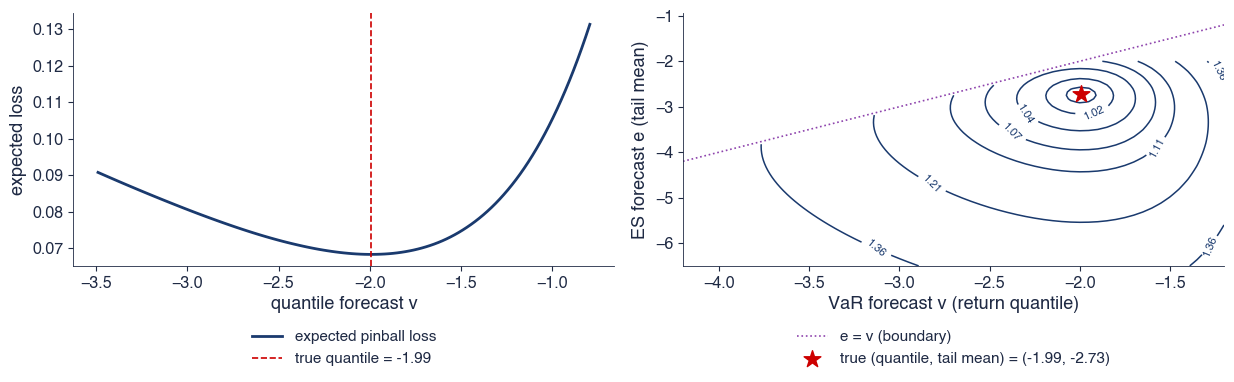

{'nu': 5, 'a': 0.025, 'v0': -1.991164127896548, 'e0': -2.7278020716416695, 'vmin': -1.9836641278965477, 'zmin_v': -2.0, 'zmin_e': -2.75, 'zmin': 1.005481653194563}


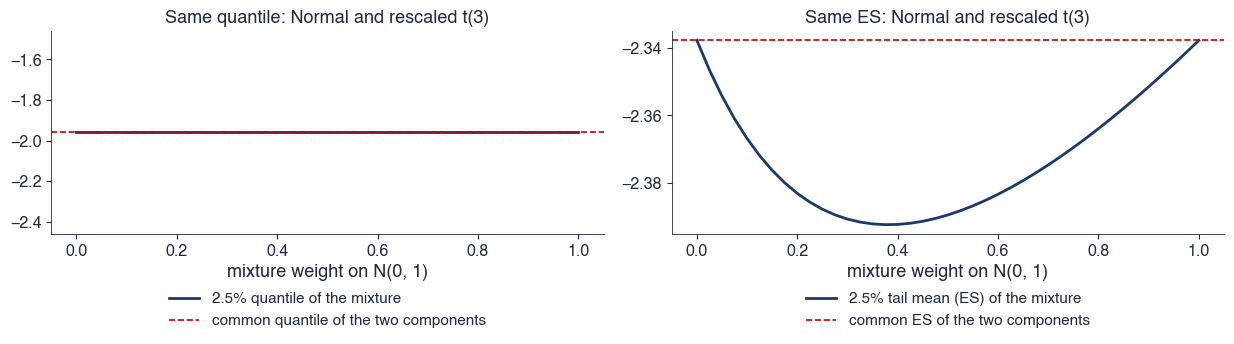

{'zq': -1.9599639845400545, 'es_n': -2.337802792201413, 'es_mid': -2.389518846261317, 'es_dev': -0.05459625950240943, 'lam_dev': 0.375, 'vq_dev': 4.813927034774679e-13, 's_t': 0.6158671023877607, 's_t1': 0.4638881359533572}


In [6]:
def fig_fz0_contour(save_it=True, nu=5, a=0.025, n=400_000):
    """Expected pinball loss (left) and expected FZ0 loss (right) for a Student t(5) scaled to unit variance; the
    minimisers are the true VaR and ES; the iso-loss contours are convex (Fissler 2017)."""
    rng = np.random.default_rng(SEED)
    y = rng.standard_t(nu, n) * np.sqrt((nu - 2) / nu)
    v0, e0 = t_std_var_es(a, nu)
    vs = np.linspace(v0 - 1.5, v0 + 1.2, 121)
    pb = np.array([pinball(y, v, a).mean() for v in vs])
    V, E = np.meshgrid(np.linspace(-4.2, -1.2, 61), np.linspace(-6.5, -2.0, 61))
    Z = np.full(V.shape, np.nan)
    ys = np.sort(y)
    cs = np.concatenate([[0], np.cumsum(ys)])
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            v, e = V[i, j], E[i, j]
            if e < v:
                k = np.searchsorted(ys, v, side='right')
                tail = (k * v - cs[k]) / n                       # E[1{y<=v}(v - y)]
                Z[i, j] = -tail / (a * e) + v / e + np.log(-e) - 1
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.1))
    axs[0].plot(vs, pb, color=st.MainBlue, lw=2, label='expected pinball loss')
    axs[0].axvline(v0, color=st.IDAred, ls='--', lw=1.2, label=f'true quantile = {v0:.2f}')
    axs[0].set_xlabel('quantile forecast v')
    axs[0].set_ylabel('expected loss')
    lv = np.nanmin(Z) + np.array([0.002, 0.01, 0.03, 0.06, 0.1, 0.2, 0.35])
    cs_ = axs[1].contour(V, E, Z, levels=lv, colors=[st.MainBlue], linewidths=1.1)
    axs[1].clabel(cs_, fmt='%.2f', fontsize=8)
    axs[1].plot([-4.2, -1.2], [-4.2, -1.2], ls=':', color=st.Purple, lw=1.2, label='e = v (boundary)')
    axs[1].scatter([v0], [e0], marker='*', s=160, color=st.IDAred, zorder=3, label=f'true (quantile, tail mean) = ({v0:.2f}, {e0:.2f})')
    i, j = np.unravel_index(np.nanargmin(Z), Z.shape)
    axs[1].set_xlabel('VaR forecast v (return quantile)')
    axs[1].set_ylabel('ES forecast e (tail mean)')
    st.legend_outside_bottom(axs[0], ncol=1, y=-0.2)
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save('ats_ch9_fz0_contour', save_it)
    return dict(nu=nu, a=a, v0=float(v0), e0=float(e0), vmin=float(vs[pb.argmin()]), zmin_v=float(V[i, j]), zmin_e=float(E[i, j]),
                zmin=float(np.nanmin(Z)))


def _cdf_pe(kind, s, nu, x):
    """cdf and partial expectation E[Y 1{Y <= x}] of a Normal(0, s^2) or a t(nu) scaled by s (closed forms)."""
    u = x / s
    if kind == 'n':
        return stats.norm.cdf(u), -s * stats.norm.pdf(u)
    return stats.t.cdf(u, nu), -s * stats.t.pdf(u, nu) * (nu + u ** 2) / (nu - 1)


def mix_var_es(lam, c0, c1, a):
    """Quantile and tail mean of the mixture lam F0 + (1 - lam) F1, each component given as (kind, scale, nu)."""
    from scipy.optimize import brentq
    F = lambda x: lam * _cdf_pe(*c0, x)[0] + (1 - lam) * _cdf_pe(*c1, x)[0] - a
    q = brentq(F, -50, 0)
    es = (lam * _cdf_pe(*c0, q)[1] + (1 - lam) * _cdf_pe(*c1, q)[1]) / a
    return q, es


def fig_level_sets(save_it=True, a=0.025):
    """Level sets under mixing: two distributions with the same alpha-quantile keep it under every mixture (convex level
    set: VaR is elicitable); two distributions with the same ES do not keep the ES (ES alone is not elicitable)."""
    zq = stats.norm.ppf(a)
    s_t = zq / stats.t.ppf(a, 3)
    es_n = -stats.norm.pdf(zq) / a
    q3 = stats.t.ppf(a, 3)
    es_t3 = -stats.t.pdf(q3, 3) * (3 + q3 ** 2) / (2 * a)
    s_t1 = es_n / es_t3
    N0, T0, T1 = ('n', 1.0, None), ('t', s_t, 3), ('t', s_t1, 3)
    lams = np.linspace(0, 1, 41)
    vq = np.array([mix_var_es(l, N0, T0, a)[0] for l in lams])
    ve = np.array([mix_var_es(l, N0, T1, a)[1] for l in lams])
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 3.8))
    axs[0].plot(lams, vq, color=st.MainBlue, lw=2, label='2.5% quantile of the mixture')
    axs[0].axhline(zq, color=st.IDAred, ls='--', lw=1.2, label='common quantile of the two components')
    axs[0].set_ylim(zq - 0.5, zq + 0.5)
    axs[0].set_xlabel('mixture weight on N(0, 1)')
    axs[0].set_title('Same quantile: Normal and rescaled t(3)')
    axs[1].plot(lams, ve, color=st.MainBlue, lw=2, label='2.5% tail mean (ES) of the mixture')
    axs[1].axhline(es_n, color=st.IDAred, ls='--', lw=1.2, label='common ES of the two components')
    axs[1].set_xlabel('mixture weight on N(0, 1)')
    axs[1].set_title('Same ES: Normal and rescaled t(3)')
    for ax in axs:
        st.legend_outside_bottom(ax, ncol=1, y=-0.22)
    plt.tight_layout()
    save('ats_ch9_level_sets', save_it)
    k = int(np.argmax(np.abs(ve - es_n)))
    return dict(zq=float(zq), es_n=float(es_n), es_mid=float(ve[20]), es_dev=float(ve[k] - es_n), lam_dev=float(lams[k]),
                vq_dev=float(np.max(np.abs(vq - zq))), s_t=float(s_t), s_t1=float(s_t1))


print(fig_fz0_contour(save_it=False, n=100_000))
print(fig_level_sets(save_it=False))

## 2. CAViaR: Engle and Manganelli (2004) on today's data

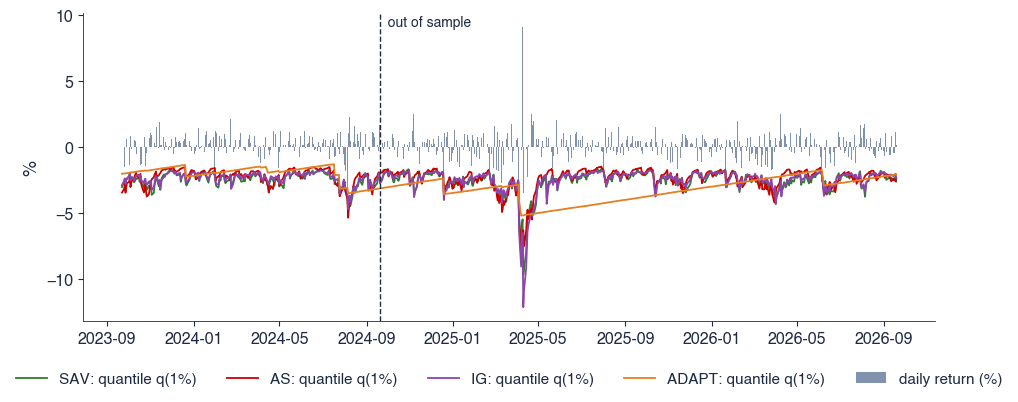

{'SAV': {'b': [0.3591555123091253, 0.7020115689464205, 0.6037441050160759], 'se': [0.21678417520960017, 0.11767404240010479, 0.24280461242713786], 'rq': np.float64(0.03304608721382559), 'f1': np.float64(2.112587512658415), 'hit_in': 0.010027662517289074, 'hit_out': 0.014, 'dq_out': (14.433268173141283, 0.025153539575173835), 'pin_out': 0.03866815788247547}, 'AS': {'b': [0.26356810262039543, 0.8050406598780542, 0.044327272950910344, 0.6161205811180265], 'se': [0.1371927731166412, 0.08039574707252312, 0.18475457801720674, 0.14883514771736595], 'rq': np.float64(0.03219652860702068), 'f1': np.float64(2.112587512658415), 'hit_in': 0.010027662517289074, 'hit_out': 0.012, 'dq_out': (15.81432519155079, 0.014786026506355939), 'pin_out': 0.036641980199319434}, 'IG': {'b': [0.9421734947779785, 0.6740654427989525, 1.429443049147749], 'se': [0.4672474298797097, 0.10461594660666751, 0.7017874827655968], 'rq': np.float64(0.032667317519424324), 'f1': np.float64(2.112587512658415), 'hit_in': 0.01002766

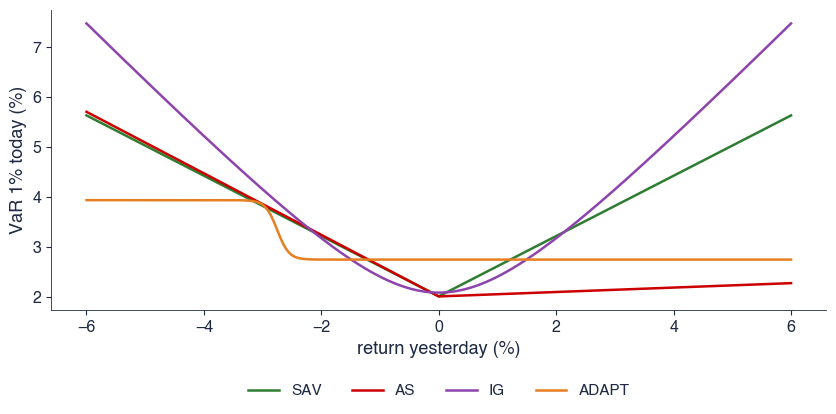

{'median': {'SAV': 2.3434857648713314, 'AS': 2.160342440402285, 'IG': 2.239540805982455, 'ADAPT': 2.7521730261549937}, 'as_ratio': 13.89935676395751}


In [7]:
def em_sample():
    """The last 3,392 S&P 500 returns to 18 September 2026: 2,892 in-sample and 500 out-of-sample days (EM, empirical section)."""
    y = returns('sp500')
    n = EM_DESIGN['n_in'] + EM_DESIGN['n_out']
    return y.iloc[-n:]


def caviar_table(theta):
    def go():
        y = em_sample()
        Y = y.values
        n_in = EM_DESIGN['n_in']
        out = {}
        for spec in ('SAV', 'AS', 'IG', 'ADAPT'):
            f = caviar_fit(spec, Y[:n_in], theta)
            se, _ = caviar_se(f, Y[:n_in])
            var = caviar_var(spec, f['b'], Y, theta, f['f1'])[:-1]
            q = -var
            dq_os = dq_test(Y[n_in:], q[n_in:], theta)
            out[spec] = dict(b=f['b'].tolist(), se=se.tolist(), rq=f['rq'], f1=f['f1'],
                             hit_in=float((Y[:n_in] < q[:n_in]).mean()), hit_out=float((Y[n_in:] < q[n_in:]).mean()),
                             dq_out=dq_os, q=q, pin_out=float(pinball(Y[n_in:], q[n_in:], theta).mean()))
        return dict(y=y, res=out)
    return cached(f'caviar_{theta}', go)


def fig_caviar(save_it=True, theta=0.01):
    """VaR 1% of the S&P 500 from the four CAViaR specifications, the last 500 days out of sample."""
    t = caviar_table(theta)
    y, res = t['y'], t['res']
    n_in = EM_DESIGN['n_in']
    idx = y.index
    fig, ax = plt.subplots(figsize=(11, 4.0))
    sel = slice(n_in - 250, None)
    ax.bar(idx[sel], y.values[sel], color=st.MainBlue, width=1.0, alpha=0.55, label='daily return (%)')
    for spec, c in zip(('SAV', 'AS', 'IG', 'ADAPT'), (st.Forest, st.IDAred, st.Purple, st.Orange)):
        ax.plot(idx[sel], res[spec]['q'][sel], color=c, lw=1.3, label=f'{spec}: quantile q(1%)')
    ax.axvline(idx[n_in], color=st.DarkText, ls='--', lw=1)
    ax.text(idx[n_in], ax.get_ylim()[1] * 0.9, '  out of sample', color=st.DarkText, fontsize=10)
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=5, y=-0.12)
    save('ats_ch9_caviar', save_it)
    out = {k: {kk: vv for kk, vv in v.items() if kk != 'q'} for k, v in res.items()}
    out['dates'] = [str(idx[0].date()), str(idx[n_in - 1].date()), str(idx[n_in].date()), str(idx[-1].date())]
    return out


def fig_nic(save_it=True, theta=0.01):
    """News impact curves of the four CAViaR models: VaR_t as a function of y_{t-1}, VaR_{t-1} at its in-sample median."""
    t = caviar_table(theta)
    res = t['res']
    xs = np.linspace(-6, 6, 241)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    med = {}
    for spec, c in zip(('SAV', 'AS', 'IG', 'ADAPT'), (st.Forest, st.IDAred, st.Purple, st.Orange)):
        m = float(np.median(-res[spec]['q'][:EM_DESIGN['n_in']]))
        med[spec] = m
        b = np.asarray(res[spec]['b'])
        nic = [caviar_var(spec, b, np.array([x]), theta, m)[1] for x in xs]
        ax.plot(xs, nic, color=c, lw=1.8, label=spec)
    ax.set_xlabel('return yesterday (%)')
    ax.set_ylabel('VaR 1% today (%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch9_nic', save_it)
    b = np.asarray(res['AS']['b'])
    return dict(median=med, as_ratio=float(b[3] / b[2]) if b[2] > 0 else None)


print(fig_caviar(save_it=False))
print(fig_nic(save_it=False))

## 3. Patton, Ziegel and Chen (2019): replication on the S&P 500

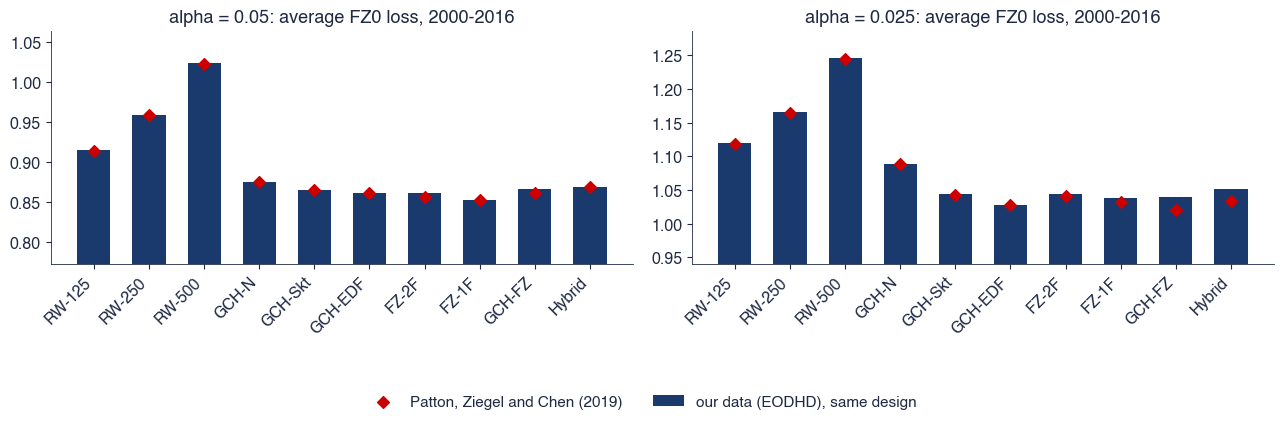

{'maxdev': {'0.05': 0.005704391012368526, '0.025': 0.01995278678246737}}


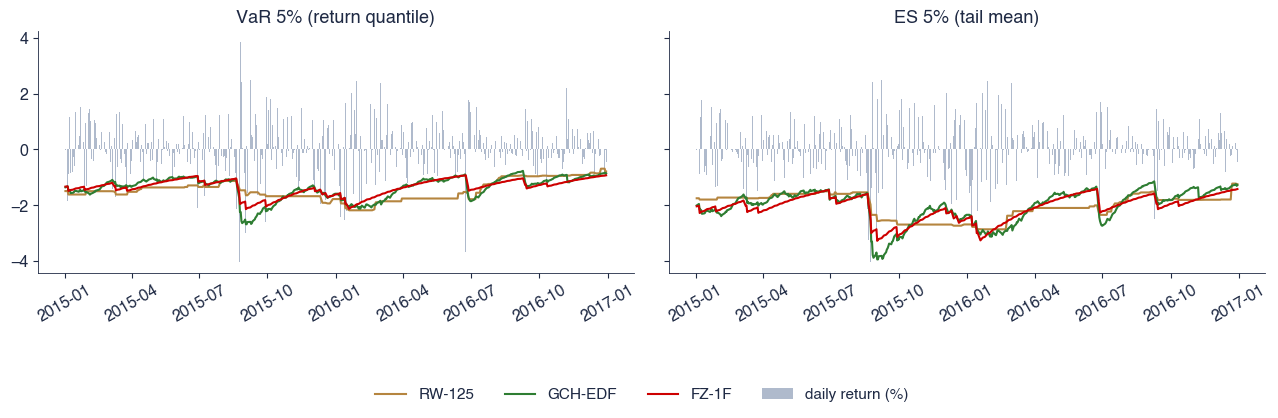

{'min_es': -9.915669912621366}


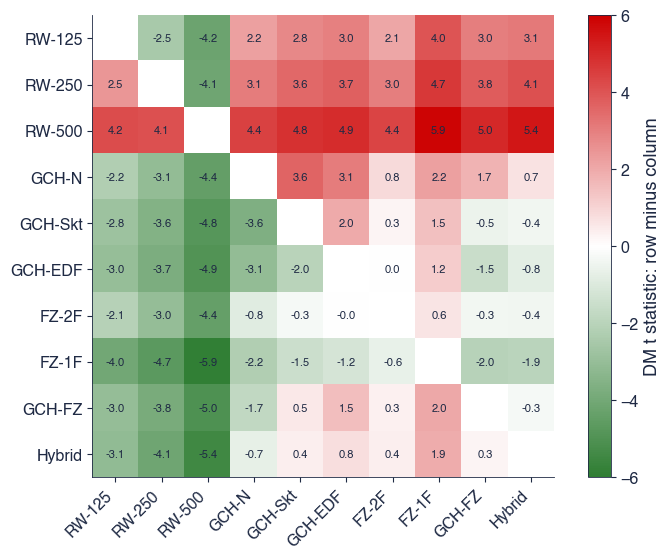

{'fz1f_col': {'RW-125': 4.022320523184996, 'RW-250': 4.657985495271352, 'RW-500': 5.868163553400199, 'GCH-N': 2.218640587864089, 'GCH-Skt': 1.4709096279434464, 'GCH-EDF': 1.18835632667034, 'FZ-2F': 0.6475924252863313, 'FZ-1F': nan, 'GCH-FZ': 2.0162965838694613, 'Hybrid': 1.9448175491446544}}


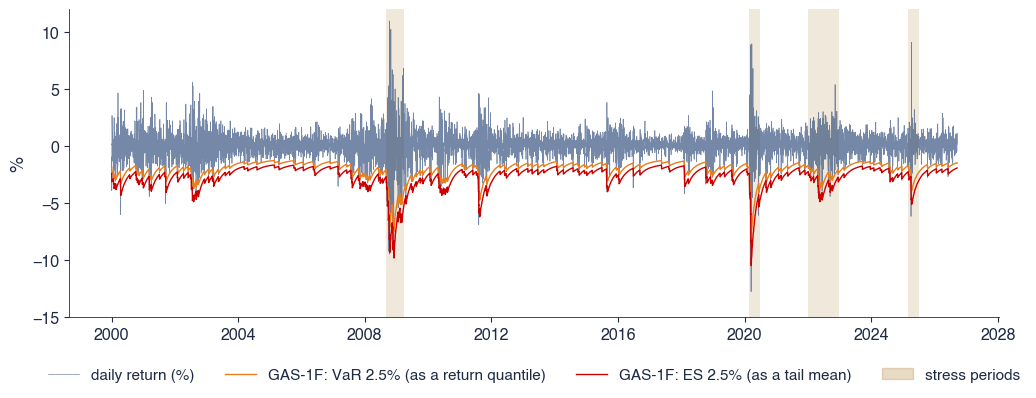

{'es_min': -10.472672950975243, 'es_min_day': '2020-03-17', 'es_med': -2.437647828184964}


In [8]:
def pzc_replication():
    """S&P 500, in-sample 1990-1999, out of sample 2000-2016: average FZ0 loss, goodness-of-fit p-values and the
    Diebold-Mariano matrix at alpha = 0.05 and 0.025, next to PZC Tables 7, 8, 9 and S5."""
    r = run_asset('sp500')
    out = dict(n_in=r['n_in'], order=list(r['fits']['order']), arma=r['fits']['arma'], garch=r['fits']['garch'],
               nu=r['fits']['nu'], lam=r['fits']['lam'])
    for a in (0.05, 0.025):
        L, idx = oos_losses(r, a, '2000-01-01', '2016-12-31')
        y = r['y']
        sel = (y.index >= '2000-01-01') & (y.index <= '2016-12-31')
        gof = {m: pzc_gof(y.values[sel], r['fc'][a][m][0][sel], r['fc'][a][m][1][sel], a) for m in MODELS}
        dm = np.array([[dm_test(L[:, i], L[:, j])[0] if i != j else np.nan for j in range(10)] for i in range(10)])
        out[str(a)] = dict(T=int(len(idx)), loss=dict(zip(MODELS, L.mean(0).tolist())), paper=PZC_TABLE[a],
                           gof={m: (g['p_var'], g['p_es']) for m, g in gof.items()}, dm=dm.tolist(),
                           fz={m: np.asarray(r['fits']['fz'][(m, a)]['p']).tolist() for m in FZ_NAMES},
                           fz_in={m: float(r['fits']['fz'][(m, a)]['loss']) for m in FZ_NAMES})
    return out


def fig_pzc_table(save_it=True):
    """Our out-of-sample average FZ0 losses against PZC Table 8 (alpha = 0.05) and Table S5 (alpha = 0.025)."""
    rep = cached('pzc_rep', pzc_replication)
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9))
    x = np.arange(10)
    for ax, a in zip(axs, (0.05, 0.025)):
        ours = [rep[str(a)]['loss'][m] for m in MODELS]
        pap = [PZC_TABLE[a][m] for m in MODELS]
        ax.bar(x, ours, color=st.MainBlue, width=0.6, label='our data (EODHD), same design')
        ax.scatter(x, pap, color=st.IDAred, marker='D', s=36, zorder=3, label='Patton, Ziegel and Chen (2019)')
        ax.set_xticks(x)
        ax.set_xticklabels(MODELS, rotation=45, ha='right')
        ax.set_ylim(min(ours + pap) - 0.08, max(ours + pap) + 0.04)
        ax.set_title(f'alpha = {a}: average FZ0 loss, 2000-2016')
    h, l = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h, l, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch9_pzc_table', save_it)
    dev = {str(a): max(abs(rep[str(a)]['loss'][m] - PZC_TABLE[a][m]) for m in MODELS) for a in (0.05, 0.025)}
    return dict(maxdev=dev)


def fig_pzc_paths(save_it=True, a=0.05):
    """PZC Figures 4-5 on our data: VaR and ES 5% of the S&P 500 from RW-125, GARCH-EDF and GAS-1F, 2015-2016."""
    r = run_asset('sp500')
    y = r['y']
    sel = (y.index >= '2015-01-01') & (y.index <= '2016-12-31')
    idx = y.index[sel]
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), sharey=True)
    for ax, k, ttl in ((axs[0], 0, 'VaR 5% (return quantile)'), (axs[1], 1, 'ES 5% (tail mean)')):
        ax.bar(idx, y.values[sel], color=st.MainBlue, alpha=0.35, width=1.0, label='daily return (%)')
        for m, c in zip(('RW-125', 'GCH-EDF', 'FZ-1F'), (st.Amber, st.Forest, st.IDAred)):
            ax.plot(idx, r['fc'][a][m][k][sel], color=c, lw=1.5, label=m)
        ax.set_title(ttl)
        ax.tick_params(axis='x', rotation=30)
    h, l = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h, l, ncol=4, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch9_pzc_paths', save_it)
    days_flat = float(np.mean(np.abs(np.diff(r['fc'][a]['FZ-1F'][0][sel])) < 1e-3 * np.abs(r['fc'][a]['FZ-1F'][0][sel][1:])))
    return dict(min_es=float(np.nanmin(r['fc'][a]['FZ-1F'][1][(y.index >= '2008-01-01') & (y.index <= '2009-12-31')])))


def fig_dm(save_it=True, a=0.05):
    """Diebold-Mariano t statistics (row minus column, FZ0 loss), S&P 500 2000-2016, as PZC Table 9."""
    rep = cached('pzc_rep', pzc_replication)
    D = np.array(rep[str(a)]['dm'], float)
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('dm', [st.Forest, '#FFFFFF', st.IDAred])
    fig, ax = plt.subplots(figsize=(8.6, 6.0))
    im = ax.imshow(np.clip(D, -6, 6), cmap=cmap, vmin=-6, vmax=6)
    for i in range(10):
        for j in range(10):
            if i != j:
                ax.text(j, i, f'{D[i, j]:.1f}', ha='center', va='center', fontsize=8, color=st.DarkText)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(MODELS, rotation=45, ha='right')
    ax.set_yticklabels(MODELS)
    cb = plt.colorbar(im, ax=ax, fraction=0.04)
    cb.set_label('DM t statistic: row minus column')
    save('ats_ch9_dm', save_it)
    j = MODELS.index('FZ-1F')
    return dict(fz1f_col=dict(zip(MODELS, D[:, j].tolist())))


def fig_overview(save_it=True, a=0.025):
    """S&P 500 returns 2000-2026 with the GAS-1F VaR and ES 2.5% forecasts (parameters fixed on 1990-1999)."""
    r = run_asset('sp500')
    y = r['y']
    sel = y.index >= '2000-01-01'
    idx = y.index[sel]
    fig, ax = plt.subplots(figsize=(12, 4.0))
    ax.plot(idx, y.values[sel], color=st.MainBlue, alpha=0.6, lw=0.5, label='daily return (%)')
    ax.plot(idx, r['fc'][a]['FZ-1F'][0][sel], color=st.Orange, lw=1.0, label='GAS-1F: VaR 2.5% (as a return quantile)')
    ax.plot(idx, r['fc'][a]['FZ-1F'][1][sel], color=st.IDAred, lw=1.0, label='GAS-1F: ES 2.5% (as a tail mean)')
    shade_stress(ax, idx)
    ax.set_ylim(-15, 12)
    ax.set_ylabel('%')
    h, l = ax.get_legend_handles_labels()
    from matplotlib.patches import Patch
    st.legend_outside_bottom(ax, ncol=4, y=-0.12, handles=h + [Patch(color=st.Amber, alpha=0.3)], labels=l + ['stress periods'])
    save('ats_ch9_overview', save_it)
    e = r['fc'][a]['FZ-1F'][1][sel]
    return dict(es_min=float(np.min(e)), es_min_day=str(idx[np.argmin(e)].date()), es_med=float(np.median(e)))


print(fig_pzc_table(save_it=False))
print(fig_pzc_paths(save_it=False))
print(fig_dm(save_it=False))
print(fig_overview(save_it=False))

## 4. A Murphy diagram for VaR 2.5%

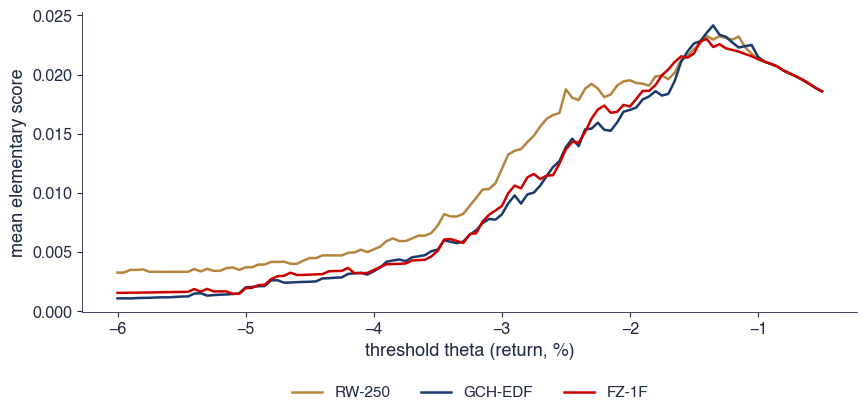

{'fz_better': 0.3783783783783784, 'edf_vs_rw': 0.9099099099099099, 'theta_cross': [-5.05, -4.9, -4.1, -4.05], 'pin': {'RW-250': 0.08590789696730436, 'GCH-EDF': 0.0745109285156395, 'FZ-1F': 0.07662698695145795}}


In [9]:
def fig_murphy(save_it=True, a=0.025):
    """Murphy diagram (Ehm et al. 2016) of three VaR 2.5% forecasts of the S&P 500, out of sample 2000-2016."""
    r = run_asset('sp500')
    y = r['y']
    sel = (y.index >= '2000-01-01') & (y.index <= '2016-12-31')
    Y = y.values[sel]
    th = np.linspace(-6, -0.5, 111)
    curves = {m: murphy_quantile(Y, r['fc'][a][m][0][sel], a, th) for m in ('RW-250', 'GCH-EDF', 'FZ-1F')}
    fig, ax = plt.subplots(figsize=(10, 3.9))
    for m, c in zip(curves, (st.Amber, st.MainBlue, st.IDAred)):
        ax.plot(th, curves[m], color=c, lw=1.8, label=m)
    ax.set_xlabel('threshold theta (return, %)')
    ax.set_ylabel('mean elementary score')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch9_murphy', save_it)
    d = curves['FZ-1F'] - curves['GCH-EDF']
    d2 = curves['GCH-EDF'] - curves['RW-250']
    return dict(fz_better=float((d <= 1e-12).mean()), edf_vs_rw=float((d2 <= 1e-12).mean()),
                theta_cross=[float(t) for t in th[1:][np.diff(np.sign(d)) != 0]][:4],
                pin=dict((m, float(pinball(Y, r['fc'][a][m][0][sel], a).mean())) for m in curves))


print(fig_murphy(save_it=False))

## 5. Joint (VaR, ES) regression on the VIX

- 30 bootstrap replications here (200 on the slides).

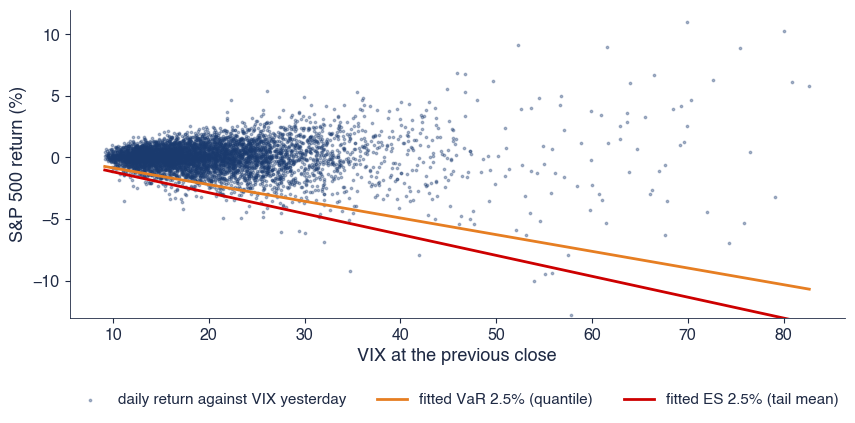

{'b': [0.49941747720179436, -0.1354078488848219], 'g': [0.5240704083056362, -0.16956345046190302], 'se': [0.15713603824587263, 0.009886174199835396, 0.22654699410370288, 0.014021534772920358], 'hit': 0.025022341376228777}


In [10]:
def fig_esreg(save_it=True, a=0.025, B=200, block=20):
    """Joint linear regression of the S&P 500 VaR and ES 2.5% on the lagged VIX, 2000-2026, by FZ0 minimisation;
    moving-block bootstrap standard errors."""
    def go():
        y = returns('sp500', start='2000-01-01')
        vx = load_close('vix', start='1999-12-01')
        x = vx.reindex(vx.index.union(y.index)).ffill().shift(1).reindex(y.index).values
        ok = np.isfinite(x)
        Y, X = y.values[ok], np.column_stack([np.ones(ok.sum()), x[ok]])
        b, g, loss, b_qr = es_regression(Y, X, a)
        rng = np.random.default_rng(SEED)
        T = len(Y)
        bs = []
        for _ in range(B):
            st_ = rng.integers(0, T - block + 1, int(np.ceil(T / block)))
            idx = (st_[:, None] + np.arange(block)).ravel()[:T]
            bb, gg, _, _ = es_regression(Y[idx], X[idx], a, n_starts=1)
            bs.append(np.concatenate([bb, gg]))
        bs = np.array(bs)
        return dict(Y=Y, X=X, b=b, g=g, loss=loss, b_qr=b_qr, se=bs.std(axis=0, ddof=1))
    r = cached('esreg', go)
    Y, X, b, g = r['Y'], r['X'], r['b'], r['g']
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.scatter(X[:, 1], Y, s=3, color=st.MainBlue, alpha=0.35, label='daily return against VIX yesterday')
    xs = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
    ax.plot(xs, b[0] + b[1] * xs, color=st.Orange, lw=2, label='fitted VaR 2.5% (quantile)')
    ax.plot(xs, g[0] + g[1] * xs, color=st.IDAred, lw=2, label='fitted ES 2.5% (tail mean)')
    ax.set_xlabel('VIX at the previous close')
    ax.set_ylabel('S&P 500 return (%)')
    ax.set_ylim(-13, 12)
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch9_esreg', save_it)
    v, e = X @ b, X @ g
    return dict(b=b.tolist(), g=g.tolist(), se=r['se'].tolist(), b_qr=np.asarray(r['b_qr']).tolist(), T=int(len(Y)),
                hit=float((Y <= v).mean()), ratio=float(g[1] / b[1]), gof=pzc_gof(Y, v, e, a))


r = fig_esreg(save_it=False, B=30)
print({k: r[k] for k in ('b', 'g', 'se', 'hit')})

## 6. Backtests across assets and models

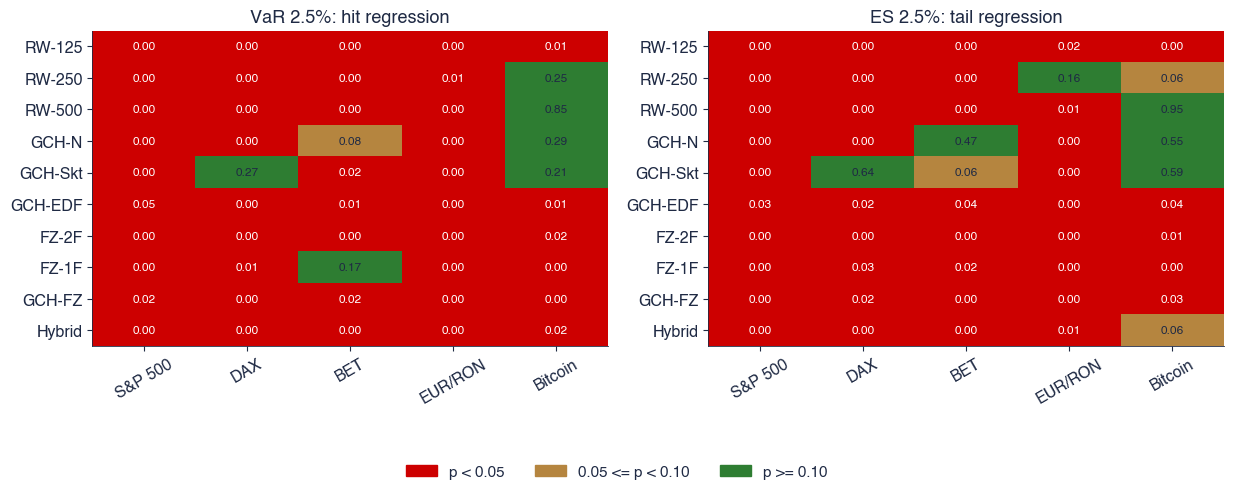

{'sp500': [], 'dax': ['GCH-Skt'], 'bet': [], 'eurron': [], 'btc': ['RW-500', 'GCH-N', 'GCH-Skt']}


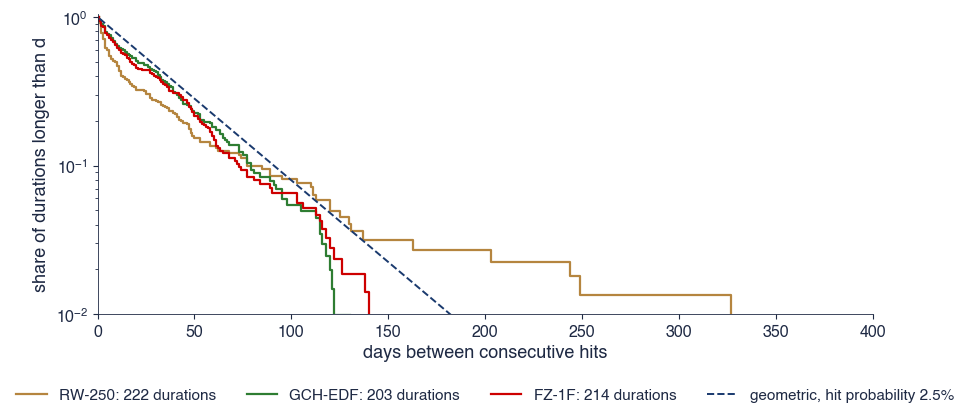

{'RW-250': {'n': 222, 'share1': 0.0945945945945946, 'share5': 0.4009009009009009, 'b': 0.6681389252249356, 'p': 5.65497445131862e-20, 'med': 9.0}, 'GCH-EDF': {'n': 203, 'share1': 0.04926108374384237, 'share5': 0.22660098522167488, 'b': 0.9161613770767537, 'p': 0.10725057638893522, 'med': 21.0}, 'FZ-1F': {'n': 214, 'share1': 0.06074766355140187, 'share5': 0.24299065420560748, 'b': 0.8848124764194611, 'p': 0.019351307271799373, 'med': 17.5}, 'geo5': 0.11890430664062512}


In [11]:
def backtest_table(a=0.025):
    """For every asset and model (out of sample to 2026): hit rate, Kupiec, Christoffersen CC, duration, DQ and the PZC
    VaR and ES regressions; McNeil-Frey for the GARCH models."""
    def go():
        out = {}
        for nm in ASSETS:
            r = run_asset(nm)
            n = r['n_in']
            Y = r['y'].values[n:]
            out[nm] = {}
            for m in MODELS:
                v, e = r['fc'][a][m][0][n:], r['fc'][a][m][1][n:]
                h = (Y <= v).astype(int)
                g = pzc_gof(Y, v, e, a)
                row = dict(hit=float(h.mean()), kupiec=kupiec(h, a)[1], cc=christoffersen(h, a)['p_cc'],
                           dur=cp_duration_test(h)[1], weib=cp_duration_test(h)[2], dq=dq_test(Y, v, a)[1],
                           gof_v=g['p_var'], gof_e=g['p_es'], loss=float(fz0(Y, v, e, a).mean()))
                if m.startswith('GCH-') and m != 'GCH-FZ':
                    row['mf'] = mcneil_frey(Y, v, e, r['sig'][n:])[1]
                out[nm][m] = row
        return out
    return cached(f'bt_{a}', go)


def fig_backtests(save_it=True, a=0.025):
    """p-values of the PZC VaR and ES goodness-of-fit regressions, ten models, five assets, out of sample to 2026."""
    bt = backtest_table(a)
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap = ListedColormap([st.IDAred, st.Amber, st.Forest])
    norm = BoundaryNorm([0, 0.05, 0.10, 1.0], 3)
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.6))
    for ax, key, ttl in ((axs[0], 'gof_v', 'VaR 2.5%: hit regression'), (axs[1], 'gof_e', 'ES 2.5%: tail regression')):
        M = np.array([[bt[nm][m][key] for nm in ASSETS] for m in MODELS])
        ax.imshow(M, cmap=cmap, norm=norm, aspect='auto')
        for i in range(10):
            for j in range(5):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=8.5, color='white' if M[i, j] < 0.05 else st.DarkText)
        ax.set_xticks(range(5))
        ax.set_xticklabels([LAB[k] for k in ASSETS], rotation=30)
        ax.set_yticks(range(10))
        ax.set_yticklabels(MODELS)
        ax.set_title(ttl)
    from matplotlib.patches import Patch
    st.fig_legend_bottom(fig, [Patch(color=st.IDAred), Patch(color=st.Amber), Patch(color=st.Forest)],
                         ['p < 0.05', '0.05 <= p < 0.10', 'p >= 0.10'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save('ats_ch9_backtests', save_it)
    passv = {nm: [m for m in MODELS if bt[nm][m]['gof_v'] >= 0.1 and bt[nm][m]['gof_e'] >= 0.1] for nm in ASSETS}
    return dict(table=bt, pass_both=passv, n_pass=int(sum(len(v) for v in passv.values())))


def fig_durations(save_it=True, a=0.025):
    """Durations between VaR 2.5% hits of the S&P 500 out of sample (2000-2026): empirical survival against the
    geometric survival implied by a correct model, RW-250 against GAS-1F."""
    r = run_asset('sp500')
    n = r['n_in']
    Y = r['y'].values[n:]
    fig, ax = plt.subplots(figsize=(10, 3.9))
    out = {}
    for m, c in (('RW-250', st.Amber), ('GCH-EDF', st.Forest), ('FZ-1F', st.IDAred)):
        h = (Y <= r['fc'][a][m][0][n:]).astype(int)
        d = np.diff(np.flatnonzero(h))
        ds = np.sort(d)
        ax.step(ds, 1 - np.arange(1, len(ds) + 1) / len(ds), where='post', color=c, lw=1.6, label=f'{m}: {len(d)} durations')
        lr, p, b = cp_duration_test(h)
        out[m] = dict(n=int(len(d)), share1=float((d == 1).mean()), share5=float((d <= 5).mean()), b=b, p=p, med=float(np.median(d)))
    xs = np.arange(1, 400)
    ax.plot(xs, (1 - a) ** xs, color=st.MainBlue, ls='--', lw=1.4, label='geometric, hit probability 2.5%')
    ax.set_yscale('log')
    ax.set_xlim(0, 400)
    ax.set_ylim(1e-2, 1.05)
    ax.set_xlabel('days between consecutive hits')
    ax.set_ylabel('share of durations longer than d')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch9_durations', save_it)
    out['geo5'] = float(1 - (1 - a) ** 5)
    return out


print(fig_backtests(save_it=False)['pass_both'])
print(fig_durations(save_it=False))

## 7. Estimation risk in backtests: a Monte Carlo

- 100 replications here (500 on the slides).

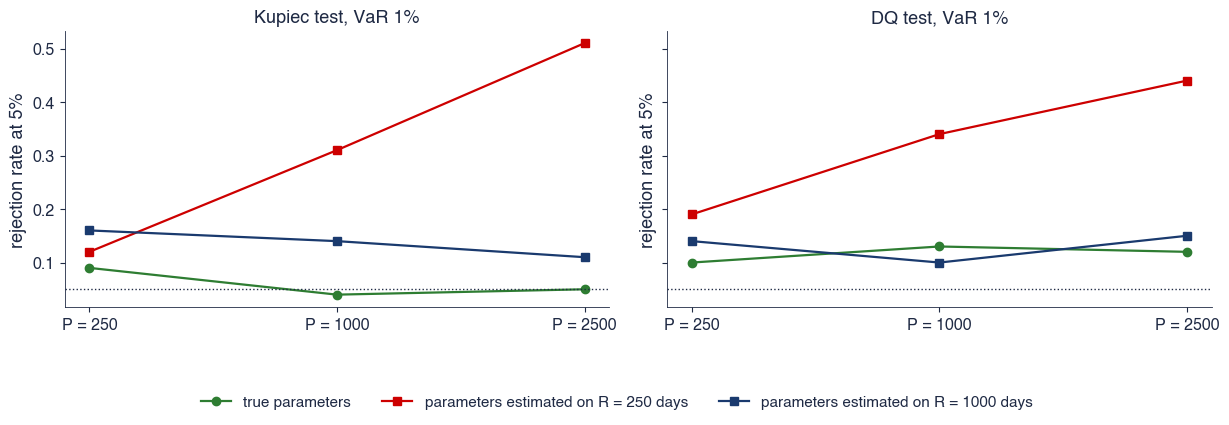

{'250_250': {'kup': 0.12, 'kup0': 0.09, 'dq': 0.19, 'dq0': 0.1, 'hit_sd': 0.013717784077612535, 'hit_mean': 0.013320000000000004}, '250_1000': {'kup': 0.31, 'kup0': 0.04, 'dq': 0.34, 'dq0': 0.13, 'hit_sd': 0.0073171032519706875, 'hit_mean': 0.0118}, '250_2500': {'kup': 0.51, 'kup0': 0.05, 'dq': 0.44, 'dq0': 0.12, 'hit_sd': 0.012765239676559152, 'hit_mean': 0.014284000000000002}, '1000_250': {'kup': 0.16, 'kup0': 0.13, 'dq': 0.14, 'dq0': 0.08, 'hit_sd': 0.0075721595334488296, 'hit_mean': 0.010320000000000001}, '1000_1000': {'kup': 0.14, 'kup0': 0.04, 'dq': 0.1, 'dq0': 0.1, 'hit_sd': 0.003747999466382032, 'hit_mean': 0.009649999999999999}, '1000_2500': {'kup': 0.11, 'kup0': 0.03, 'dq': 0.15, 'dq0': 0.08, 'hit_sd': 0.0024400000000000003, 'hit_mean': 0.010359999999999998}, 'reps': 100}


In [12]:
def sim_garch(T, omega, alpha, beta, rng, burn=500):
    z = rng.standard_normal(T + burn)
    y = np.empty(T + burn)
    h = omega / (1 - alpha - beta)
    for t in range(T + burn):
        y[t] = np.sqrt(h) * z[t]
        h = omega + alpha * y[t] ** 2 + beta * h
    return y[burn:]


def fig_estrisk_mc(save_it=True, reps=500, a=0.01, Rs=(250, 1000), Ps=(250, 1000, 2500)):
    """Size of the Kupiec and DQ tests at 5% for VaR 1% when the GARCH(1,1) parameters are estimated on R days (fixed
    scheme) and the test uses P out-of-sample days; Normal GARCH data, correct model (Escanciano and Olmo 2010)."""
    def go():
        rng = np.random.default_rng(SEED)
        om, al, be = 0.02, 0.08, 0.90
        z = stats.norm.ppf(a)
        res = {}
        for R in Rs:
            for P in Ps:
                rk = rd = rk0 = rd0 = 0
                hits = []
                for _ in range(reps):
                    y = sim_garch(R + P, om, al, be, rng)
                    p = garch_fit(y[:R])
                    s = garch_sigma(y, p, h0=np.var(y[:R]))[:-1]
                    s0 = garch_sigma(y, np.array([om, al, be]), h0=om / (1 - al - be))[:-1]
                    q, q0 = z * s[R:], z * s0[R:]
                    Yo = y[R:]
                    h, h0 = (Yo <= q).astype(int), (Yo <= q0).astype(int)
                    hits.append(h.mean())
                    rk += kupiec(h, a)[1] < 0.05
                    rk0 += kupiec(h0, a)[1] < 0.05
                    rd += dq_test(Yo, q, a)[1] < 0.05
                    rd0 += dq_test(Yo, q0, a)[1] < 0.05
                res[(R, P)] = dict(kup=rk / reps, kup0=rk0 / reps, dq=rd / reps, dq0=rd0 / reps, hit_sd=float(np.std(hits)),
                                   hit_mean=float(np.mean(hits)))
        return res
    res = cached('estrisk_mc', go)
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 3.9), sharey=True)
    x = np.arange(len(Ps))
    for ax, key, ttl in ((axs[0], 'kup', 'Kupiec test, VaR 1%'), (axs[1], 'dq', 'DQ test, VaR 1%')):
        ax.plot(x, [res[(Rs[0], P)][key + '0'] for P in Ps], 'o-', color=st.Forest, lw=1.6, label='true parameters')
        for R, c in zip(Rs, (st.IDAred, st.MainBlue)):
            ax.plot(x, [res[(R, P)][key] for P in Ps], 's-', color=c, lw=1.6, label=f'parameters estimated on R = {R} days')
        ax.axhline(0.05, color=st.DarkText, ls=':', lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels([f'P = {P}' for P in Ps])
        ax.set_title(ttl)
        ax.set_ylabel('rejection rate at 5%')
    h, l = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch9_estrisk_mc', save_it)
    return {f'{R}_{P}': v for (R, P), v in res.items()} | dict(reps=reps)


print(fig_estrisk_mc(save_it=False, reps=100))

## 8. Stress periods and model confidence sets

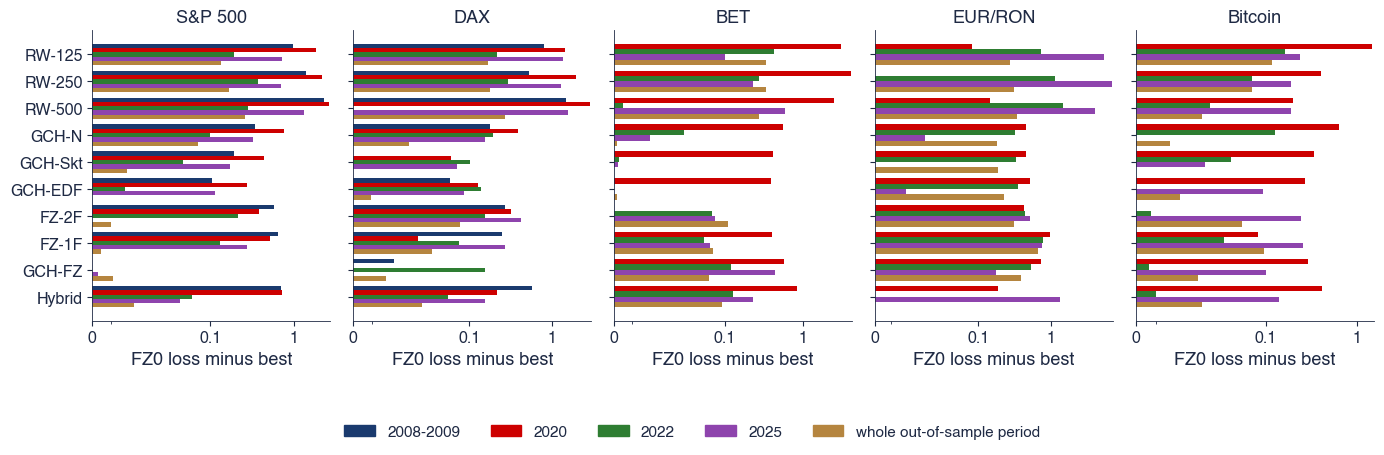

{'sp500': {'2008': 'GCH-FZ', '2020': 'GCH-FZ', '2022': 'GCH-FZ', '2025': 'FZ-2F', 'full': 'GCH-EDF'}, 'dax': {'2008': 'GCH-Skt', '2020': 'GCH-FZ', '2022': 'RW-500', '2025': 'GCH-FZ', 'full': 'GCH-Skt'}, 'bet': {'2020': 'FZ-2F', '2022': 'GCH-EDF', '2025': 'GCH-EDF', 'full': 'GCH-Skt'}, 'eurron': {'2020': 'RW-250', '2022': 'Hybrid', '2025': 'GCH-Skt', 'full': 'Hybrid'}, 'btc': {'2020': 'FZ-2F', '2022': 'GCH-EDF', '2025': 'GCH-N', 'full': 'GCH-Skt'}}


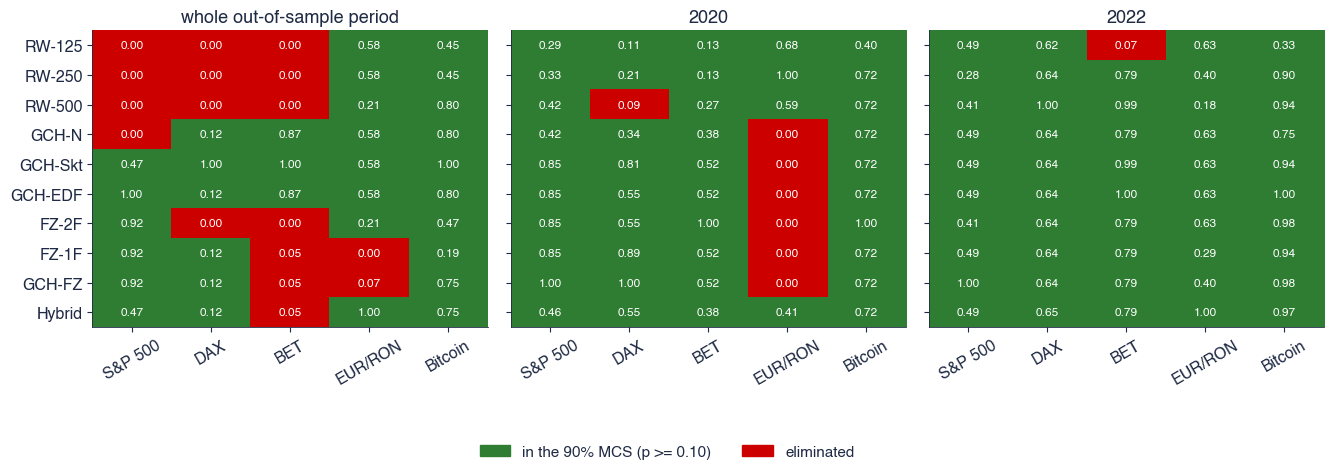

{'sizes': {'full': {'sp500': 6, 'dax': 6, 'bet': 3, 'eurron': 8, 'btc': 10}, '2020': {'sp500': 10, 'dax': 9, 'bet': 10, 'eurron': 4, 'btc': 10}, '2022': {'sp500': 10, 'dax': 10, 'bet': 9, 'eurron': 10, 'btc': 10}}}


In [13]:
def comparison(a=0.025):
    def go():
        out = {}
        for nm in ASSETS:
            r = run_asset(nm)
            L, idx = oos_losses(r, a)
            res = dict(T=int(len(idx)), start=str(idx[0].date()), loss=dict(zip(MODELS, L.mean(0).tolist())),
                       mcs=mcs(L, MODELS, B=1000, block=10)['p'])
            per = {}
            for k, (s, e) in STRESS.items():
                Lp, ip = oos_losses(r, a, s, e)
                if len(ip) < 40 or ip[0] > pd.Timestamp(s) + pd.Timedelta(days=10):
                    continue
                per[k] = dict(T=int(len(ip)), loss=dict(zip(MODELS, Lp.mean(0).tolist())), mcs=mcs(Lp, MODELS, B=1000, block=5)['p'],
                              hits=int(sum((r['y'].loc[s:e].values <= r['fc'][a]['FZ-1F'][0][(r['y'].index >= s) & (r['y'].index <= e)]))))
            res['periods'] = per
            out[nm] = res
        return out
    return cached(f'cmp_{a}', go)


def fig_stress(save_it=True, a=0.025):
    """Average FZ0 loss of each model in the stress periods, minus that of the best model in the period, per asset."""
    cp = comparison(a)
    fig, axs = plt.subplots(1, 5, figsize=(14, 4.2), sharey=True)
    cols = {'2008': st.MainBlue, '2020': st.IDAred, '2022': st.Forest, '2025': st.Purple, 'full': st.Amber}
    for ax, nm in zip(axs, ASSETS):
        per = dict(cp[nm]['periods'])
        per['full'] = dict(loss=cp[nm]['loss'])
        ks = [k for k in ('2008', '2020', '2022', '2025', 'full') if k in per]
        w = 0.8 / len(ks)
        for i, k in enumerate(ks):
            lo = np.array([per[k]['loss'][m] for m in MODELS])
            ax.barh(np.arange(10) + (i - len(ks) / 2 + 0.5) * w, lo - lo.min(), height=w, color=cols[k],
                    label=('whole out-of-sample period' if k == 'full' else k))
        ax.set_yticks(range(10))
        ax.set_yticklabels(MODELS)
        ax.invert_yaxis()
        ax.set_xscale('symlog', linthresh=0.05)
        ax.set_xticks([0, 0.1, 1])
        ax.set_xticklabels(['0', '0.1', '1'])
        ax.set_title(LAB[nm])
        ax.set_xlabel('FZ0 loss minus best')
    handles = [plt.Rectangle((0, 0), 1, 1, color=cols[k]) for k in ('2008', '2020', '2022', '2025', 'full')]
    st.fig_legend_bottom(fig, handles, ['2008-2009', '2020', '2022', '2025', 'whole out-of-sample period'], ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save('ats_ch9_stress', save_it)
    best = {nm: {k: min(v['loss'], key=v['loss'].get) for k, v in cp[nm]['periods'].items()} | {'full': min(cp[nm]['loss'], key=cp[nm]['loss'].get)}
            for nm in ASSETS}
    return dict(best=best, cmp=cp)


def fig_mcs(save_it=True, a=0.025):
    """90% model confidence sets (FZ0 loss): MCS p-values over the whole out-of-sample period and over 2020 and 2022."""
    cp = comparison(a)
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap = ListedColormap([st.IDAred, st.Forest])
    norm = BoundaryNorm([0, 0.10, 1.0], 2)
    fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=True)
    sizes = {}
    for ax, k, ttl in ((axs[0], 'full', 'whole out-of-sample period'), (axs[1], '2020', '2020'), (axs[2], '2022', '2022')):
        M = np.array([[(cp[nm]['mcs'] if k == 'full' else cp[nm]['periods'][k]['mcs'])[m] for nm in ASSETS] for m in MODELS])
        ax.imshow(M, cmap=cmap, norm=norm, aspect='auto')
        for i in range(10):
            for j in range(5):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=8.5, color='white')
        ax.set_xticks(range(5))
        ax.set_xticklabels([LAB[n_] for n_ in ASSETS], rotation=30)
        ax.set_yticks(range(10))
        ax.set_yticklabels(MODELS)
        ax.set_title(ttl)
        sizes[k] = {nm: int((M[:, j] >= 0.10).sum()) for j, nm in enumerate(ASSETS)}
    from matplotlib.patches import Patch
    st.fig_legend_bottom(fig, [Patch(color=st.Forest), Patch(color=st.IDAred)], ['in the 90% MCS (p >= 0.10)', 'eliminated'], ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save('ats_ch9_mcs', save_it)
    return dict(sizes=sizes)


print(fig_stress(save_it=False)['best'])
print(fig_mcs(save_it=False))

## 9. The horizon: 10-day VaR against the square-root-of-time rule

- 500 simulated paths per day here (2000 on the slides).

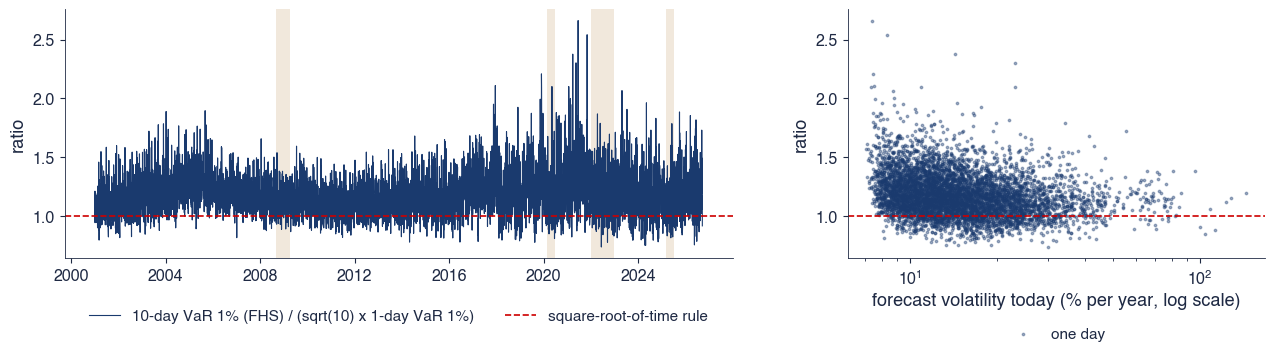

{'r_lo': 1.2316868745451042, 'r_hi': 1.108862844717634, 'r_med': 1.1608465038210287, 'r_min': 0.7379808086750671, 'r_max': 2.661040678463831, 'n': 646, 'hit_fhs': 0.007739938080495356, 'hit_sqrt': 0.010835913312693499, 'kup_fhs': 0.5477206350214499, 'kup_sqrt': 0.8331339144310218, 'n_fhs': 5, 'n_sqrt': 7}


In [14]:
def fhs_hday(name='sp500', h=10, a=0.01, start='2001-01-01', win=2000, refit=250, npath=2000):
    """10-day VaR 1% by filtered historical simulation from a GJR-GARCH(1,1) (Gaussian QMLE, rolling 2000-day window,
    re-estimated every 250 days): bootstrapped standardised residuals pushed through the variance recursion."""
    def go():
        y = returns(name)
        Y = y.values - 0.0
        first = int((y.index < start).sum())
        rng = np.random.default_rng(SEED)
        v1, vh, sig = [], [], []
        p = None
        for t in range(first, len(Y)):
            if p is None or (t - first) % refit == 0:
                seg = Y[t - win:t]
                mu = seg.mean()
                p = garch_fit(seg - mu, gjr=True)
                s = garch_sigma(seg - mu, p, gjr=True)
                zres = (seg - mu) / s[:-1]
                hist = Y[:t] - mu
            # one-step variance from the filtered path up to t-1
            st_ = garch_sigma(Y[t - win:t] - mu, p, gjr=True)[-1]
            hnext = st_ ** 2
            zz = rng.choice(zres, size=(npath, h))
            hh = np.full(npath, hnext)
            cum = np.zeros(npath)
            for k in range(h):
                eps = np.sqrt(hh) * zz[:, k]
                cum += mu + eps
                hh = p[0] + (p[1] + p[2] * (eps < 0)) * eps ** 2 + p[3] * hh
            v1.append(-(mu + st_ * np.quantile(zres, a)))
            vh.append(-np.quantile(cum, a))
            sig.append(st_)
        idx = y.index[first:]
        return pd.DataFrame({'var1': v1, 'varh': vh, 'sig': sig}, index=idx), y
    return cached(f'fhs_{name}_{h}', go)


def fig_sqrt(save_it=True, h=10, a=0.01, npath=2000):
    """Ratio of the 10-day VaR 1% by FHS to sqrt(10) x the 1-day VaR 1%, S&P 500, 2001-2026; non-overlapping backtest."""
    df, y = fhs_hday('sp500', h, a, npath=npath)
    ratio = df['varh'] / (np.sqrt(h) * df['var1'])
    Y = y.values
    pos = np.searchsorted(y.index, df.index)
    fwd = np.array([Y[p:p + h].sum() if p + h <= len(Y) else np.nan for p in pos])
    ok = np.isfinite(fwd)
    nonov = np.arange(0, ok.sum(), h)
    f = fwd[ok][nonov]
    vh = df['varh'].values[ok][nonov]
    vs = np.sqrt(h) * df['var1'].values[ok][nonov]
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1.6, 1]))
    axs[0].plot(df.index, ratio, color=st.MainBlue, lw=0.8, label='10-day VaR 1% (FHS) / (sqrt(10) x 1-day VaR 1%)')
    axs[0].axhline(1, color=st.IDAred, ls='--', lw=1.2, label='square-root-of-time rule')
    shade_stress(axs[0], df.index)
    axs[0].set_ylabel('ratio')
    vol = df['sig'] * np.sqrt(252)
    axs[1].scatter(vol, ratio, s=3, color=st.MainBlue, alpha=0.4, label='one day')
    axs[1].axhline(1, color=st.IDAred, ls='--', lw=1.2)
    axs[1].set_xscale('log')
    axs[1].set_xlabel('forecast volatility today (% per year, log scale)')
    axs[1].set_ylabel('ratio')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.15)
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.22)
    plt.tight_layout()
    save('ats_ch9_sqrt', save_it)
    lo = vol < vol.quantile(0.2)
    hi = vol > vol.quantile(0.8)
    return dict(r_lo=float(ratio[lo].median()), r_hi=float(ratio[hi].median()), r_med=float(ratio.median()),
                r_min=float(ratio.min()), r_max=float(ratio.max()), n=int(len(f)),
                hit_fhs=float((f < -vh).mean()), hit_sqrt=float((f < -vs).mean()),
                kup_fhs=kupiec((f < -vh).astype(int), a)[1], kup_sqrt=kupiec((f < -vs).astype(int), a)[1],
                n_fhs=int((f < -vh).sum()), n_sqrt=int((f < -vs).sum()))


print(fig_sqrt(save_it=False, npath=500))

## 10. Model risk and estimation risk

- 40 bootstrap re-estimations here (150 on the slides).

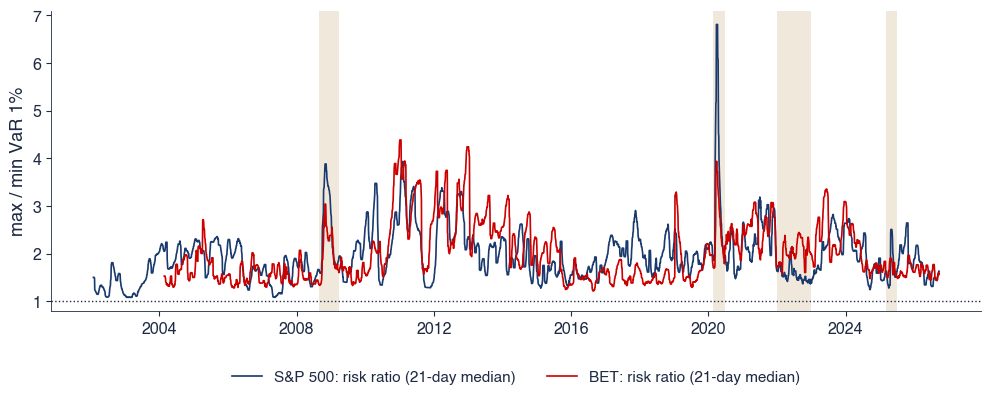

1.8684996797155027


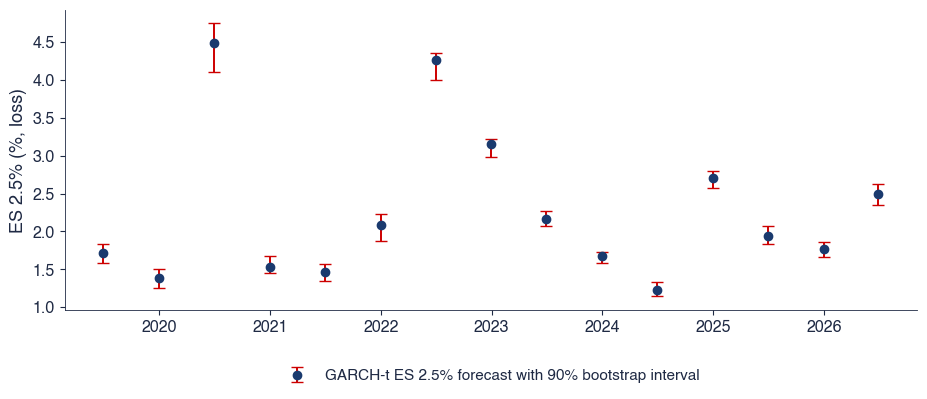

0.12378112937697311


In [15]:
def six_models(name, a=0.01, start='2002-01-01', win=1000, refit=125):
    """VaR 1% from six standard model families, rolling 1000-day windows: historical simulation, Normal with the window
    volatility, EWMA (lambda = 0.94), GARCH-N, GARCH-t, filtered HS (GARCH-EDF)."""
    def go():
        y = returns(name)
        Y = y.values
        first = max(int((y.index < start).sum()), win + 1)
        out = {k: [] for k in ('HS', 'MA-N', 'EWMA', 'GARCH-N', 'GARCH-t', 'FHS')}
        zN = stats.norm.ppf(a)
        ew = np.var(Y[first - win:first])
        for t in range(first - win, first):
            ew = 0.94 * ew + 0.06 * Y[t] ** 2
        for t in range(first, len(Y)):
            seg = Y[t - win:t]
            if (t - first) % refit == 0:
                mu = seg.mean()
                pn = garch_fit(seg - mu)
                pt = garch_fit(seg - mu, dist='t')
                sn = garch_sigma(seg - mu, pn)
                zres = (seg - mu) / sn[:-1]
                qf = np.quantile(zres, a)
                tq = t_std_var_es(a, pt[-1])[0]
            sn_t = garch_sigma(seg - mu, pn)[-1]
            st_t = garch_sigma(seg - mu, pt[:3])[-1]
            out['HS'].append(-np.quantile(seg, a))
            out['MA-N'].append(-(seg.mean() + seg.std() * zN))
            out['EWMA'].append(-np.sqrt(ew) * zN)
            out['GARCH-N'].append(-(mu + sn_t * zN))
            out['GARCH-t'].append(-(mu + st_t * tq))
            out['FHS'].append(-(mu + sn_t * qf))
            ew = 0.94 * ew + 0.06 * Y[t] ** 2
        return pd.DataFrame(out, index=y.index[first:]), y
    return cached(f'six_{name}', go)


def fig_riskratio(save_it=True):
    """Risk ratio max/min of the six VaR 1% forecasts (Danielsson et al. 2016), S&P 500 and BET, 2002-2026."""
    fig, ax = plt.subplots(figsize=(12, 3.9))
    out = {}
    for nm, c in (('sp500', st.MainBlue), ('bet', st.IDAred)):
        df, y = six_models(nm)
        rr = df.max(axis=1) / df.min(axis=1)
        ax.plot(rr.index, rr.rolling(21).median(), color=c, lw=1.2, label=f'{LAB[nm]}: risk ratio (21-day median)')
        hits = {k: float((y.reindex(df.index).values < -df[k].values).mean()) for k in df}
        out[nm] = dict(med=float(rr.median()), q90=float(rr.quantile(0.9)), mx=float(rr.max()), mx_day=str(rr.idxmax().date()),
                       s2008=float(rr.loc['2008-09-01':'2009-03-31'].median()), s2020=float(rr.loc['2020-02-19':'2020-06-30'].median()),
                       calm=float(rr.loc['2017-01-01':'2017-12-31'].median()), hits=hits,
                       argmax=df.idxmax(axis=1).value_counts(normalize=True).to_dict(), argmin=df.idxmin(axis=1).value_counts(normalize=True).to_dict())
    shade_stress(ax, rr.index)
    ax.axhline(1, color=st.DarkText, ls=':', lw=1)
    ax.set_ylabel('max / min VaR 1%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch9_riskratio', save_it)
    return out


def fig_es_ci(save_it=True, a=0.025, B=150, win=2000):
    """Estimation risk: GARCH-t ES 2.5% forecasts of the S&P 500 at half-year ends 2019-2026 with 90% parametric
    bootstrap intervals (re-estimation on simulated paths, the forecast conditional on the observed history)."""
    def go():
        y = returns('sp500')
        Y = y.values
        dates = pd.date_range('2019-06-30', '2026-06-30', freq='6ME')
        rng = np.random.default_rng(SEED)
        rows = []
        for d in dates:
            t = int((y.index <= d).sum())
            seg = Y[t - win:t]
            mu = seg.mean()
            p = garch_fit(seg - mu, dist='t')
            s = garch_sigma(seg - mu, p[:3])
            zq, ze = t_std_var_es(a, p[-1])
            es = -(mu + s[-1] * ze)
            bs = []
            for _ in range(B):
                nu = p[-1]
                zz = rng.standard_t(nu, win) * np.sqrt((nu - 2) / nu)
                hsim, ysim = p[0] / (1 - p[1] - p[2]), np.empty(win)
                for k in range(win):
                    ysim[k] = np.sqrt(hsim) * zz[k]
                    hsim = p[0] + p[1] * ysim[k] ** 2 + p[2] * hsim
                r_ = optimize.minimize(garch_negll, p, args=(ysim, 't', False), method='Nelder-Mead', options={'maxiter': 3000})
                pb = r_.x
                sb = garch_sigma(seg - mu, pb[:3])[-1]
                bs.append(-(mu + sb * t_std_var_es(a, max(pb[-1], 2.1))[1]))
            bs = np.array(bs)
            rows.append(dict(date=str(d.date()), es=float(es), lo=float(np.quantile(bs, 0.05)), hi=float(np.quantile(bs, 0.95)),
                             nu=float(p[-1])))
        return rows
    rows = cached('es_ci', go)
    df = pd.DataFrame(rows)
    df['date'] = pd.to_datetime(df['date'])
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.errorbar(df['date'], df['es'], yerr=[df['es'] - df['lo'], df['hi'] - df['es']], fmt='o', color=st.MainBlue,
                ecolor=st.IDAred, capsize=4, lw=1.4, label='GARCH-t ES 2.5% forecast with 90% bootstrap interval')
    ax.set_ylabel('ES 2.5% (%, loss)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.15)
    save('ats_ch9_es_ci', save_it)
    rel = (df['hi'] - df['lo']) / df['es']
    return dict(rows=rows, rel_med=float(rel.median()), rel_max=float(rel.max()), rel_min=float(rel.min()),
                rel_max_day=str(df['date'][rel.idxmax()].date()))


print(fig_riskratio(save_it=False)['sp500']['med'])
print(fig_es_ci(save_it=False, B=40)['rel_med'])

## 11. Extremal index and adaptive conformal calibration

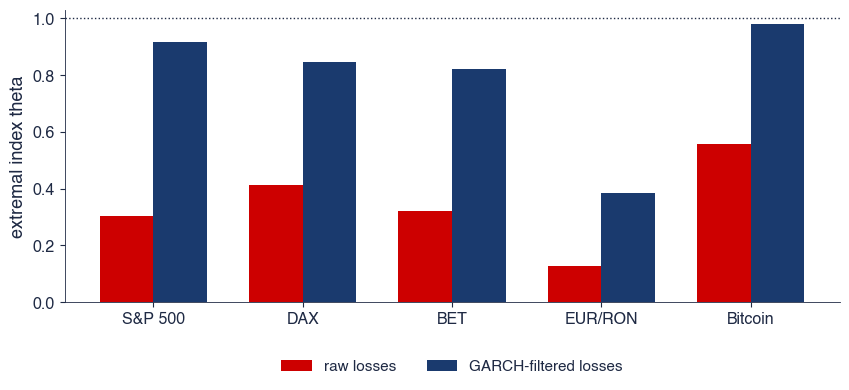

{'sp500': {'raw': 0.30314338631187165, 'filt': 0.9178950695044819}, 'dax': {'raw': 0.4133718523547116, 'filt': 0.8452374175637086}, 'bet': {'raw': 0.32078876105010007, 'filt': 0.8229830234825694}, 'eurron': {'raw': 0.12713778933764786, 'filt': 0.38604594258394825}, 'btc': {'raw': 0.5558631231741411, 'filt': 0.9816698788028727}}


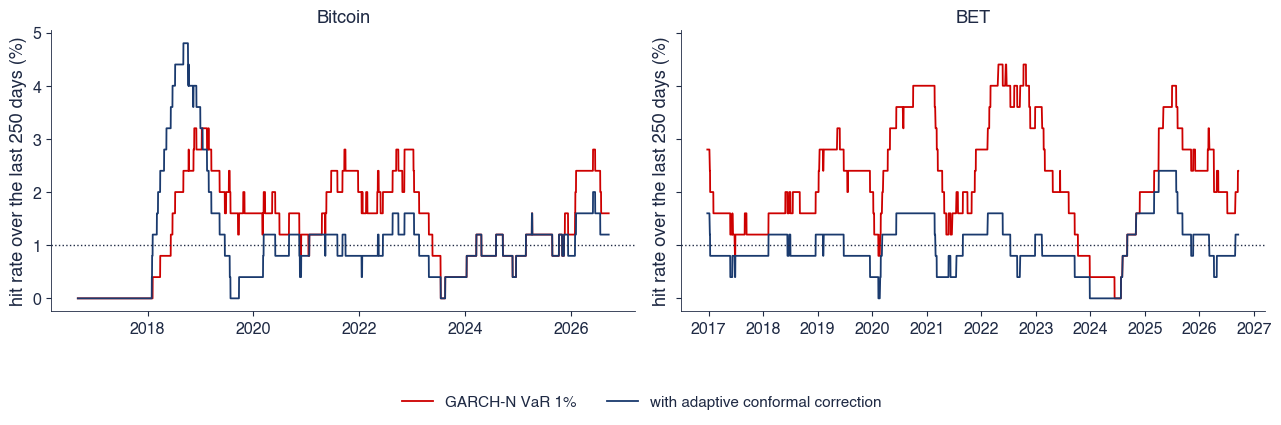

{'btc': {'base': 0.012774655084312723, 'aci': 0.010219724067450179, 'at_min': -0.012299999999999, 'at_end': 0.005650000000000619, 'kup_base': 0.0943660799980394, 'kup_aci': 0.8905091864987839, 'cc_base': 0.22503078122280945, 'cc_aci': 0.6551951113868221, 'T': 3914, 'rmax_base': 0.032, 'rmax_aci': 0.048}, 'bet': {'base': 0.02355140186915888, 'aci': 0.010841121495327103, 'at_min': -0.0045500000000001, 'at_end': -0.0013000000000001472, 'kup_base': 2.045233556082478e-09, 'kup_aci': 0.6662071208703517, 'cc_base': 1.4171307785331812e-08, 'cc_aci': 0.6624221456403259, 'T': 2675, 'rmax_base': 0.044, 'rmax_aci': 0.024}}


In [16]:
def fig_extremal(save_it=True, q=0.95):
    """Extremal index (Ferro-Segers intervals estimator) of daily losses above their 95% quantile, raw and filtered by
    the in-sample ARMA-GARCH (standardised residuals), whole sample."""
    out = {}
    for nm in ASSETS:
        r = run_asset(nm)
        L = -r['y'].values
        z = -(r['y'].values - r['mu']) / r['sig']
        out[nm] = dict(raw=extremal_index(L, np.quantile(L, q)), filt=extremal_index(z, np.quantile(z, q)))
    fig, ax = plt.subplots(figsize=(10, 3.8))
    x = np.arange(5)
    ax.bar(x - 0.18, [out[k]['raw'] for k in ASSETS], width=0.36, color=st.IDAred, label='raw losses')
    ax.bar(x + 0.18, [out[k]['filt'] for k in ASSETS], width=0.36, color=st.MainBlue, label='GARCH-filtered losses')
    ax.axhline(1, color=st.DarkText, ls=':', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([LAB[k] for k in ASSETS])
    ax.set_ylabel('extremal index theta')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch9_extremal', save_it)
    return out


def conformal_base(nm, a=0.01, gamma=0.005, start='2016-01-01', win=1000, refit=250):
    """GARCH-N VaR 1% (rolling 1000-day window, re-estimated every 250 days) from 2016 and its adaptive conformal
    correction (Gibbs and Candes 2021) with step gamma."""
    def go():
        y = returns(nm)
        Y = y.values
        first = int((y.index < start).sum())
        mus, sig = np.empty(len(Y) - first), np.empty(len(Y) - first)
        for t in range(first, len(Y)):
            seg = Y[t - win:t]
            if (t - first) % refit == 0:
                mu = seg.mean()
                p = garch_fit(seg - mu)
            mus[t - first] = mu
            sig[t - first] = garch_sigma(seg - mu, p)[-1]
        Yo = Y[first:]
        base = (Yo < mus + sig * stats.norm.ppf(a)).astype(float)
        f = lambda t, at: float(Yo[t] < mus[t] + sig[t] * stats.norm.ppf(min(max(at, 1e-5), 0.5)))
        at, err = aci_levels(f, a, gamma, len(Yo))
        return pd.DataFrame({'y': Yo, 'mu': mus, 'sig': sig, 'base': base, 'aci': err, 'at': at[:-1]}, index=y.index[first:])
    return cached(f'confb_{nm}', go)


def fig_conformal(save_it=True, a=0.01):
    """Rolling 250-day hit rates of the GARCH-N VaR 1% and of its ACI correction (gamma = 0.005), Bitcoin and BET."""
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), sharey=True)
    out = {}
    for ax, nm in zip(axs, ('btc', 'bet')):
        df = conformal_base(nm)
        ax.plot(df.index, df['base'].rolling(250).mean() * 100, color=st.IDAred, lw=1.3, label='GARCH-N VaR 1%')
        ax.plot(df.index, df['aci'].rolling(250).mean() * 100, color=st.MainBlue, lw=1.3, label='with adaptive conformal correction')
        ax.axhline(100 * a, color=st.DarkText, ls=':', lw=1)
        ax.set_title(LAB[nm])
        ax.set_ylabel('hit rate over the last 250 days (%)')
        out[nm] = dict(base=float(df['base'].mean()), aci=float(df['aci'].mean()), at_min=float(df['at'].min()),
                       at_end=float(df['at'].iloc[-1]), kup_base=kupiec(df['base'].astype(int).values, a)[1],
                       kup_aci=kupiec(df['aci'].astype(int).values, a)[1],
                       cc_base=christoffersen(df['base'].astype(int).values, a)['p_cc'],
                       cc_aci=christoffersen(df['aci'].astype(int).values, a)['p_cc'], T=int(len(df)),
                       rmax_base=float(df['base'].rolling(250).mean().max()), rmax_aci=float(df['aci'].rolling(250).mean().max()))
    h, l = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h, l, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch9_conformal', save_it)
    return out


print(fig_extremal(save_it=False))
print(fig_conformal(save_it=False))

## 12. AI mini-case: is there a best ES model?

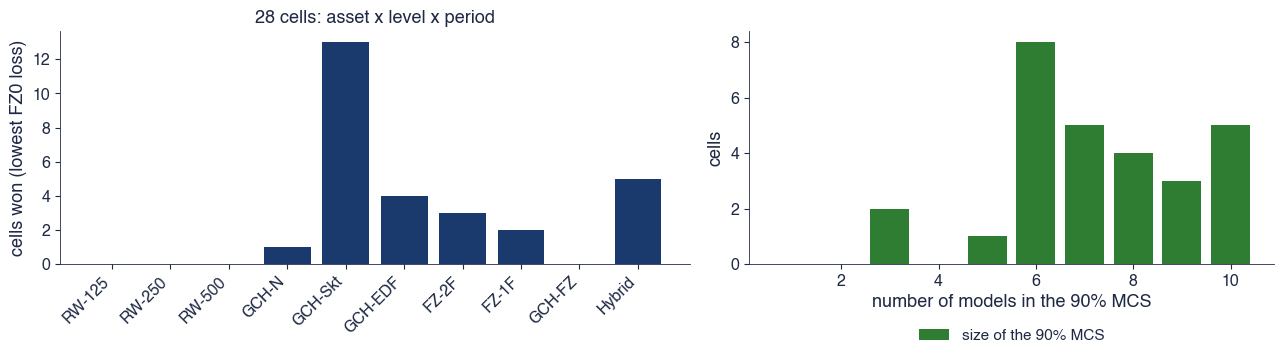

{'GCH-Skt': 13, 'Hybrid': 5, 'GCH-EDF': 4, 'FZ-2F': 3, 'FZ-1F': 2, 'GCH-N': 1} 7.0


In [17]:
def fig_ai_case(save_it=True):
    """Is there a ``best'' ES model? Winner (lowest average FZ0 loss) and 90% MCS size for each asset, level
    (2.5%, 5%) and period (whole out-of-sample period; before 2020; from 2020)."""
    rows = []
    for nm in ASSETS:
        r = run_asset(nm)
        for a in (0.025, 0.05):
            for per, (s, e) in (('whole', (None, None)), ('before 2020', (None, '2019-12-31')), ('from 2020', ('2020-01-01', None))):
                L, idx = oos_losses(r, a, s, e)
                if len(idx) < 500:
                    continue
                m = L.mean(0)
                ms = mcs(L, MODELS, B=500, block=10)
                rows.append(dict(asset=nm, a=a, per=per, win=MODELS[int(np.argmin(m))], size=len(ms['set']),
                                 fz1f_in=('FZ-1F' in ms['set'])))
    t = pd.DataFrame(rows)
    wins = t['win'].value_counts()
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1.2, 1]))
    axs[0].bar(range(len(MODELS)), [wins.get(m, 0) for m in MODELS], color=st.MainBlue)
    axs[0].set_xticks(range(len(MODELS)))
    axs[0].set_xticklabels(MODELS, rotation=45, ha='right')
    axs[0].set_ylabel('cells won (lowest FZ0 loss)')
    axs[0].set_title(f'{len(t)} cells: asset x level x period')
    axs[1].hist(t['size'], bins=np.arange(0.5, 11.5, 1), color=st.Forest, rwidth=0.8, label='size of the 90% MCS')
    axs[1].set_xlabel('number of models in the 90% MCS')
    axs[1].set_ylabel('cells')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.22)
    plt.tight_layout()
    save('ats_ch9_ai_case', save_it)
    return dict(n=int(len(t)), wins=wins.to_dict(), size_med=float(t['size'].median()), size_min=int(t['size'].min()),
                size_max=int(t['size'].max()), fz1f_in=int(t['fz1f_in'].sum()), n_win_models=int((wins > 0).sum()),
                rows=rows)


r = fig_ai_case(save_it=False)
print(r['wins'], r['size_med'])

## Exercises

1. Re-estimate the GAS-1F and GARCH-EDF models every year (rolling 10-year window) and repeat the MCS.
2. Replace the VIX by the lagged realised volatility (Chapter 8) in the joint (VaR, ES) regression.
3. Wrap the AS CAViaR in adaptive conformal inference and test it with DQ.